# Retinex-Enhanced Smoke Detection — Thesis Pipeline
**Garay & Rañola — A Retinex-Based Framework for Real-Time Low-Light Image
Enhancement in Vision-Based Smoke Detection Systems**

This notebook implements the methodology described in Chapter 3. **Every Retinex
variant is now trained and evaluated with YOLOv9** — there is no longer a step that
picks a single "winner" variant before training.

1. Build a working image subset from D-Fire (local disk, fast I/O).
2. Generate all **4 Retinex variants** (SSR, MSR, MSRCR, AMSRCR) on that subset.
3. Compute **no-reference image-quality metrics** (entropy, contrast, colorfulness)
   for each variant — *descriptive only, no selection*.
4. Train YOLOv9 (GELAN-C) **5 times**: Baseline + one run per Retinex variant
   (identical hyperparameters for every run).
5. Apply **ByteTrack** temporal validation + the **Section 3.4 mathematical
   smoke-characterization criteria** as a combined validation layer (Section 3.5.4),
   once per Retinex variant.
6. Evaluate everything (Precision / Recall / F1 / mAP@0.5 / FPS) and
   auto-generate the results tables + comparison charts.
7. Save everything to Google Drive and zip the working datasets.

> Every training run, evaluation and video run **skips itself if its result is already
> on Drive**, so the notebook can be resumed across Colab sessions. If you already have
> the earlier AMSRCR run (`smoke_retinex_weights`, `video_results_partial.json`), set
> `REUSE_EXISTING_AMSRCR = True` in Section 8 to reuse it instead of retraining.

# Imports

---
## 0. GPU Check & Google Drive Mount

In [ ]:
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected.')

CUDA available: True
GPU: NVIDIA L4


In [ ]:
import os
from google.colab import drive

if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except Exception:
        pass

drive.mount('/content/drive')

DRIVE_THESIS_DIR = '/content/drive/MyDrive/THESIZZZ'
SAVE_DIR = f'{DRIVE_THESIS_DIR}/Results'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Drive folder exists:', os.path.isdir(DRIVE_THESIS_DIR))
print('Results will be saved to:', SAVE_DIR)

Mounted at /content/drive
Drive folder exists: True
Results will be saved to: /content/drive/MyDrive/THESIZZZ/Results


---
## 1. Install Dependencies

In [ ]:
# Core deep learning + vision
!pip install -q opencv-python-headless numpy matplotlib Pillow tqdm scipy PyYAML scikit-image

# ByteTrack dependencies
!pip install -q lap cython_bbox filterpy

# Evaluation / results
!pip install -q pycocotools seaborn pandas

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 80.9 MB/s eta 0:00:00


---
## 2. Clone YOLOv9, Download Weights & Patch torch.load

In [ ]:
if not os.path.exists('/content/yolov9'):
    !git clone -q https://github.com/WongKinYiu/yolov9 /content/yolov9
else:
    print('YOLOv9 already cloned.')

%cd /content/yolov9
!pip install -q -r requirements.txt


/content/yolov9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.1 MB/s eta 0:00:00


In [ ]:
%cd /content/yolov9

if not os.path.exists('gelan-c.pt'):
    !wget -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt
    print('gelan-c.pt downloaded.')
else:
    print('gelan-c.pt already exists.')

print('Weight file size:', os.path.getsize('gelan-c.pt') // (1024 * 1024), 'MB')


/content/yolov9
gelan-c.pt downloaded.
Weight file size: 49 MB


In [ ]:
%cd /content/yolov9

if not os.path.exists('yolov9-c.pt'):
    !wget -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
    print('yolov9-c.pt downloaded.')
else:
    print('yolov9-c.pt already exists.')

print('Weight file size:', os.path.getsize('yolov9-c.pt') // (1024 * 1024), 'MB')

/content/yolov9
yolov9-c.pt downloaded.
Weight file size: 98 MB


In [ ]:
import subprocess

result = subprocess.run(
    ['find', '/content/yolov9', '-name', '*.py', '-exec', 'sed', '-i',
     r"s/torch\.load(\(.*\)map_location='cpu')/torch.load(\1map_location='cpu', weights_only=False)/g",
     '{}', '+'],
    capture_output=True, text=True
)
print('torch.load patch applied across all .py files in /content/yolov9')

check = subprocess.run(
    ['grep', '-rn', 'torch.load(', '/content/yolov9', '--include=*.py'],
    capture_output=True, text=True
)
unfixed = [l for l in check.stdout.splitlines() if 'weights_only' not in l]
print(f'Remaining unpatched torch.load calls: {len(unfixed)}')
for l in unfixed[:10]:
    print(' ', l)

torch.load patch applied across all .py files in /content/yolov9
Remaining unpatched torch.load calls: 3
  /content/yolov9/utils/loggers/__init__.py:104:            run_id = torch.load(self.weights).get('wandb_id') if self.opt.resume and not wandb_artifact_resume else None
  /content/yolov9/utils/general.py:999:    x = torch.load(f, map_location=torch.device('cpu'))
  /content/yolov9/hubconf.py:53:                ckpt = torch.load(attempt_download(path), map_location=device)  # load


---
## 3. Dataset Setup & Subset Sampling

Your D-Fire dataset has ~8,400 images which causes T4 session timeouts.
This section copies a **random subset to local disk** (`/content/smoke_subset`)
so training reads from fast local storage instead of Google Drive, then
zips it automatically (per the "auto-zip every new subset" convention used
throughout this notebook).

Expected Drive structure:
```
THESIZZZ/
  D-Fire/
    train/
      images/   labels/
    test/
      images/   labels/
    smoke.yaml
```


In [ ]:
DRIVE_THESIS_DIR = '/content/drive/MyDrive/THESIZZZ'

ORIG_TRAIN_IMGS   = f'{DRIVE_THESIS_DIR}/D-Fire/train/images'
ORIG_TRAIN_LABELS = f'{DRIVE_THESIS_DIR}/D-Fire/train/labels'
ORIG_VAL_IMGS     = f'{DRIVE_THESIS_DIR}/D-Fire/test/images'
ORIG_VAL_LABELS   = f'{DRIVE_THESIS_DIR}/D-Fire/test/labels'

for p in [ORIG_TRAIN_IMGS, ORIG_TRAIN_LABELS, ORIG_VAL_IMGS, ORIG_VAL_LABELS]:
    status = 'Found' if os.path.exists(p) else 'Not Found'
    print(f'{status}: {p}')

Not Found: /content/drive/MyDrive/THESIZZZ/D-Fire/train/images
Not Found: /content/drive/MyDrive/THESIZZZ/D-Fire/train/labels
Not Found: /content/drive/MyDrive/THESIZZZ/D-Fire/test/images
Not Found: /content/drive/MyDrive/THESIZZZ/D-Fire/test/labels


In [ ]:
import random

# Subset settings
SUBSET_DIR  = '/content/smoke_subset'
MAX_TRAIN   = 4000
MAX_VAL     = 800
SEED        = 1

random.seed(SEED)

In [ ]:
import glob
import shutil
from tqdm import tqdm

def copy_subset(img_src, lbl_src, img_dst, lbl_dst, max_n, split_name):
    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(lbl_dst, exist_ok=True)

    all_imgs = glob.glob(f'{img_src}/*.jpg') + glob.glob(f'{img_src}/*.png')
    sampled  = random.sample(all_imgs, min(max_n, len(all_imgs)))
    copied   = 0

    for img_path in tqdm(sampled, desc=f'Copying {split_name}'):
        fname    = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_src, fname + '.txt')
        if not os.path.exists(lbl_path):
            continue
        shutil.copy(img_path, img_dst)
        shutil.copy(lbl_path, lbl_dst)
        copied += 1

    print(f'  {split_name}: {len(all_imgs)} available -> {copied} copied')
    return copied


print('Building dataset subset...')
n_train = copy_subset(
    ORIG_TRAIN_IMGS, ORIG_TRAIN_LABELS,
    f'{SUBSET_DIR}/train/images', f'{SUBSET_DIR}/train/labels',
    MAX_TRAIN, 'train'
)
n_val = copy_subset(
    ORIG_VAL_IMGS, ORIG_VAL_LABELS,
    f'{SUBSET_DIR}/valid/images', f'{SUBSET_DIR}/valid/labels',
    MAX_VAL, 'valid'
)

print(f'\nSubset ready -> {n_train} train / {n_val} val  at {SUBSET_DIR}')

Building dataset subset...


Copying train:  33%|███▎      | 1332/4000 [35:08<1:05:18,  1.47s/it]

In [ ]:
# YAML for the baseline subset
SUBSET_YAML = '/content/smoke_subset.yaml'
with open(SUBSET_YAML, 'w') as f:
    f.write(f'train: {SUBSET_DIR}/train/images\n')
    f.write(f'val:   {SUBSET_DIR}/valid/images\n')
    f.write('nc: 1\n')
    f.write("names: ['smoke']\n")
print('Subset YAML written:', SUBSET_YAML)

Subset YAML written: /content/smoke_subset.yaml


In [ ]:
# Zipping Subsets for Session
def zip_dataset(dataset_dir, yaml_path=None):

    if yaml_path and os.path.exists(yaml_path):
        bundled_yaml = os.path.join(dataset_dir, os.path.basename(yaml_path))
        shutil.copy(yaml_path, bundled_yaml)

    zip_path = shutil.make_archive(
        base_name=dataset_dir,
        format='zip',
        root_dir=os.path.dirname(dataset_dir),
        base_dir=os.path.basename(dataset_dir)
    )
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f'  Zipped: {zip_path} ({size_mb:.1f} MB)')
    return zip_path

baseline_zip = zip_dataset(SUBSET_DIR, SUBSET_YAML)

NameError: name 'SUBSET_YAML' is not defined

# Checkpoint 1: Smoke Subset

In [ ]:
import zipfile

ZIP_SOURCE_DIR = '/content'
EXTRACT_TO      = '/content'

zip_path = os.path.join(ZIP_SOURCE_DIR, 'smoke_subset.zip')

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(EXTRACT_TO)
    print(f'Extracted: smoke_subset.zip -> {EXTRACT_TO}')
else:
    print(f'MISSING: {zip_path}')

Extracted: smoke_subset.zip -> /content


In [ ]:
# Define paths
SUBSET_DIR  = '/content/smoke_subset'
SUBSET_YAML = '/content/smoke_subset/smoke_subset.yaml'

---
## 4. Retinex Enhancement Module (SSR / MSR / MSRCR / AMSRCR)

Single canonical definition of all four variants (Section 3.5.1). The earlier
version of this notebook re-defined `single_scale_retinex` /
`multi_scale_retinex` / `automated_msrcr` a second time inside the comparison
cell, which silently shadowed these functions — removed here so there is only
one implementation used everywhere in the pipeline.


In [ ]:
import cv2
import numpy as np

def single_scale_retinex(image: np.ndarray, sigma: float) -> np.ndarray:
    """Single-Scale Retinex"""
    gaussian = cv2.GaussianBlur(image, (0, 0), sigma)
    retinex  = np.log1p(image.astype(np.float32)) - np.log1p(gaussian.astype(np.float32))
    return retinex


def multi_scale_retinex(image: np.ndarray, sigmas=(15, 80, 200)) -> np.ndarray:
    """Multi-Scale Retinex"""
    msr = np.zeros_like(image, dtype=np.float32)
    for sigma in sigmas:
        msr += single_scale_retinex(image, sigma)
    msr /= len(sigmas)
    return msr


def ssr_enhance(image_bgr: np.ndarray, sigma: float = 15) -> np.ndarray:
    """Single-Scale Retinex enhancement."""
    img    = image_bgr.astype(np.float32) + 1.0
    result = np.zeros_like(img)
    for c in range(3):
        ch = single_scale_retinex(img[:, :, c], sigma)
        result[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)
    return np.clip(result * 255, 0, 255).astype(np.uint8)


def msr_enhance(image_bgr: np.ndarray, sigmas=(15, 80, 200)) -> np.ndarray:
    """Multi-Scale Retinex enhancement no color restoration."""
    img    = image_bgr.astype(np.float32) + 1.0
    result = np.zeros_like(img)
    for c in range(3):
        ch = multi_scale_retinex(img[:, :, c], sigmas)
        result[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)
    return np.clip(result * 255, 0, 255).astype(np.uint8)


def retinex_enhance(image_bgr: np.ndarray, sigmas=(15, 80, 200)) -> np.ndarray:
    """
    MSRCR pipeline (Section 3.5.1):
      1. Convert to float
      2. Apply MSR per channel
      3. Color restoration
      4. Normalize to [0, 255] uint8
    """
    img = image_bgr.astype(np.float32) + 1.0

    msr_channels = [multi_scale_retinex(img[:, :, c], sigmas) for c in range(3)]
    msr = np.stack(msr_channels, axis=2)

    total         = np.sum(img, axis=2, keepdims=True)
    color_restore = np.log1p(125.0 * img / (total + 1e-6))
    msr           = msr * color_restore

    for c in range(3):
        ch = msr[:, :, c]
        msr[:, :, c] = (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)

    return np.clip(msr * 255, 0, 255).astype(np.uint8)


def automated_msrcr(image_bgr: np.ndarray, sigmas=(15, 80, 200),
                     alpha: float = 125, beta: float = 46) -> np.ndarray:
    """
    AMSRCR — per-channel MSR with color restoration + automatic gain/offset
    determined from the mean/std of each channel (no fixed normalization).
    """
    img_f  = image_bgr.astype(np.float32) + 1.0
    result = np.zeros_like(img_f)
    total  = np.sum(img_f, axis=2) + 1e-6

    for c in range(3):
        ch        = img_f[:, :, c]
        msr       = multi_scale_retinex(ch, sigmas)
        cr        = beta * (np.log(alpha * ch) - np.log(total))
        msrcr_ch  = msr * cr
        mean, std = msrcr_ch.mean(), msrcr_ch.std() + 1e-6
        result[:, :, c] = np.clip((msrcr_ch - mean) / std * 64 + 128, 0, 255)

    return np.uint8(result)


VARIANT_FUNCS = {
    'ssr'    : ssr_enhance,
    'msr'    : msr_enhance,
    'msrcr'  : retinex_enhance,
    'amsrcr' : automated_msrcr,
}

print('Retinex module loaded: SSR, MSR, MSRCR, AMSRCR ready.')

Retinex module loaded: SSR, MSR, MSRCR, AMSRCR ready.


Scored 3965 images.


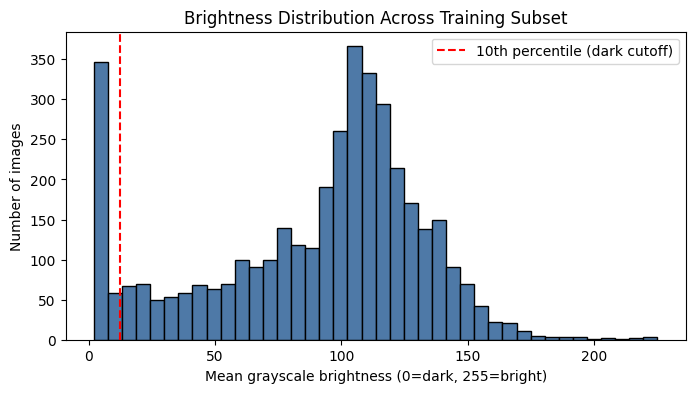

Darkest image  : /content/smoke_subset/train/images/AoF04567.jpg  (brightness=2.0)
Median image   : /content/smoke_subset/train/images/WEB08916.jpg  (brightness=101.6)
Brightest image: /content/smoke_subset/train/images/WEB09014.jpg  (brightness=225.1)


In [ ]:
import glob
import matplotlib.pyplot as plt

SUBSET_DIR = '/content/smoke_subset'

# Compute brightness for every training image
img_paths = glob.glob(f'{SUBSET_DIR}/train/images/*.jpg') + \
            glob.glob(f'{SUBSET_DIR}/train/images/*.png')

brightness_scores = []
for p in img_paths:
    img = cv2.imread(p)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()  # 0 = pure black, 255 = pure white
    brightness_scores.append((p, mean_brightness))

print(f'Scored {len(brightness_scores)} images.')

# Sort darkest to brightest
brightness_scores.sort(key=lambda x: x[1])

# Show the brightness distribution
values = [b for _, b in brightness_scores]
plt.figure(figsize=(8, 4))
plt.hist(values, bins=40, color='#4e79a7', edgecolor='black')
plt.axvline(np.percentile(values, 10), color='red', linestyle='--', label='10th percentile (dark cutoff)')
plt.title('Brightness Distribution Across Training Subset')
plt.xlabel('Mean grayscale brightness (0=dark, 255=bright)')
plt.ylabel('Number of images')
plt.legend()
plt.show()

print(f'Darkest image  : {brightness_scores[0][0]}  (brightness={brightness_scores[0][1]:.1f})')
print(f'Median image   : {brightness_scores[len(brightness_scores)//2][0]}  (brightness={brightness_scores[len(brightness_scores)//2][1]:.1f})')
print(f'Brightest image: {brightness_scores[-1][0]}  (brightness={brightness_scores[-1][1]:.1f})')

Selected low-light image: /content/smoke_subset/train/images/AoF04683.jpg  (brightness=4.7)


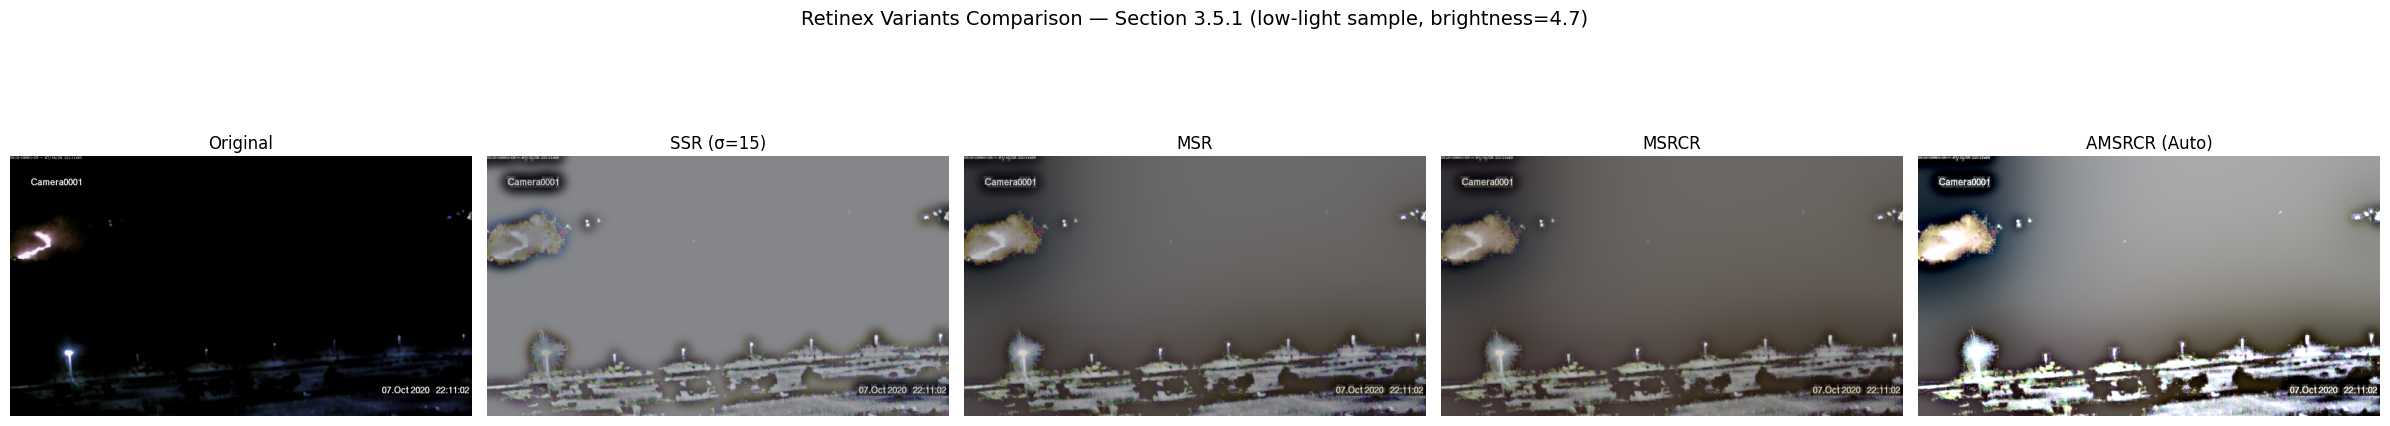

In [ ]:
# Pick an image from the darkest 10% (not the single absolute darkest,
# which could be a corrupted/black frame -- a representative dark one is safer)
dark_candidates = brightness_scores[:max(1, len(brightness_scores)//10)]
chosen_path, chosen_brightness = dark_candidates[len(dark_candidates)//2]  # median of the dark group

print(f'Selected low-light image: {chosen_path}  (brightness={chosen_brightness:.1f})')

img_bgr = cv2.imread(chosen_path)

display_variants = {
    'Original'      : img_bgr,
    'SSR (σ=15)'    : ssr_enhance(img_bgr),
    'MSR'           : msr_enhance(img_bgr),
    'MSRCR'         : retinex_enhance(img_bgr),
    'AMSRCR (Auto)' : automated_msrcr(img_bgr),
}

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, (title, img) in zip(axes, display_variants.items()):
    display = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if len(img.shape) == 2 \
               else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(display)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle(f'Retinex Variants Comparison — Section 3.5.1 (low-light sample, brightness={chosen_brightness:.1f})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Checkpoint 2: Retinex Enhanced Datasets
To be used for variant scoring.

In [ ]:
import zipfile

ZIP_SOURCE_DIR = '/content'
EXTRACT_TO      = '/content'

ENHANCED_ZIP_NAMES = [
    'smoke_subset_ssr.zip',
    'smoke_subset_msr.zip',
    'smoke_subset_msrcr.zip',
    'smoke_subset_amsrcr.zip',
]

for zip_name in ENHANCED_ZIP_NAMES:
    zip_path = os.path.join(ZIP_SOURCE_DIR, zip_name)

    if not os.path.exists(zip_path):
        print(f'MISSING: {zip_path}')
        continue

    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(EXTRACT_TO)

    print(f'Extracted: {zip_name} -> {EXTRACT_TO}')

Extracted: smoke_subset_ssr.zip -> /content
Extracted: smoke_subset_msr.zip -> /content
Extracted: smoke_subset_msrcr.zip -> /content
Extracted: smoke_subset_amsrcr.zip -> /content


---
## 5. Generate All 4 Retinex Enhanced Datasets

Each variant dataset is written to disk, given its own YAML, and **auto-zipped
with the YAML bundled inside** the moment it's finished — consistent with the
"zip every new subset automatically" behavior established earlier. **All 4
datasets are used for full YOLOv9 training** (Section 8).

In [ ]:
import shutil
from tqdm import tqdm

def enhance_folder(src_img, src_lbl, dst_img, dst_lbl, split_name, fn, variant_name):
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)

    all_imgs = glob.glob(f'{src_img}/*.jpg') + glob.glob(f'{src_img}/*.png')
    for img_path in tqdm(all_imgs, desc=f'[{variant_name}] {split_name}'):
        fname = os.path.basename(img_path)
        stem  = os.path.splitext(fname)[0]

        img = cv2.imread(img_path)
        if img is None:
            continue
        enhanced  = fn(img)
        new_fname = stem + f'_{variant_name}' + os.path.splitext(fname)[1]
        cv2.imwrite(os.path.join(dst_img, new_fname), enhanced)

        lbl_src = os.path.join(src_lbl, stem + '.txt')
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, os.path.join(dst_lbl, stem + f'_{variant_name}.txt'))

    print(f'  [{variant_name}] {split_name}: {len(all_imgs)} images done.')


ENHANCED_BASE = '/content'
variant_yaml_paths = {}
variant_zip_paths  = {}

for variant_name, fn in VARIANT_FUNCS.items():
    dataset_dir = f'{ENHANCED_BASE}/smoke_subset_{variant_name}'
    yaml_path   = f'{ENHANCED_BASE}/smoke_subset_{variant_name}.yaml'

    print(f'\n-- Generating {variant_name.upper()} dataset --')
    for split in ['train', 'valid']:
        enhance_folder(
            f'{SUBSET_DIR}/{split}/images',
            f'{SUBSET_DIR}/{split}/labels',
            f'{dataset_dir}/{split}/images',
            f'{dataset_dir}/{split}/labels',
            split, fn, variant_name
        )

    with open(yaml_path, 'w') as f:
        f.write(f'train: {dataset_dir}/train/images\n')
        f.write(f'val:   {dataset_dir}/valid/images\n')
        f.write('nc: 1\n')
        f.write("names: ['smoke']\n")

    variant_yaml_paths[variant_name] = yaml_path
    print(f'  YAML written: {yaml_path}')

    variant_zip_paths[variant_name] = zip_dataset(dataset_dir, yaml_path)

print('\nAll 4 enhanced datasets ready (generated + zipped):')
for k in VARIANT_FUNCS:
    print(f'  {k.upper():<8} -> YAML: {variant_yaml_paths[k]}')
    print(f'  {"":<8}   ZIP:  {variant_zip_paths[k]}')



-- Generating SSR dataset --


NameError: name 'glob' is not defined

---
## 6. Image Quality of the 4 Variants — No-Reference Metrics (descriptive only)

Entropy, contrast, and colorfulness are computed per variant, normalized, and
averaged into a composite score. This is now **purely descriptive** — it shows how
each variant changes the image, but it **does not choose** which variant gets
trained. All four variants go through YOLOv9 training in Section 8, so detection
performance is compared directly instead of being inferred from image quality.

In [ ]:
ENHANCED_BASE = '/content'

variant_yaml_paths = {
    'ssr'    : f'{ENHANCED_BASE}/smoke_subset_ssr/smoke_subset_ssr.yaml',
    'msr'    : f'{ENHANCED_BASE}/smoke_subset_msr/smoke_subset_msr.yaml',
    'msrcr'  : f'{ENHANCED_BASE}/smoke_subset_msrcr/smoke_subset_msrcr.yaml',
    'amsrcr' : f'{ENHANCED_BASE}/smoke_subset_amsrcr/smoke_subset_amsrcr.yaml',
}

# Verify they all exist
for k, v in variant_yaml_paths.items():
    exists = 'YES' if os.path.exists(v) else 'MISSING'
    print(f'  {k.upper():<8} → {v} {exists}')

  SSR      → /content/smoke_subset_ssr/smoke_subset_ssr.yaml YES
  MSR      → /content/smoke_subset_msr/smoke_subset_msr.yaml YES
  MSRCR    → /content/smoke_subset_msrcr/smoke_subset_msrcr.yaml YES
  AMSRCR   → /content/smoke_subset_amsrcr/smoke_subset_amsrcr.yaml YES


In [ ]:
from skimage.measure import shannon_entropy
import pandas as pd
import glob

VARIANT_NAMES = ['ssr', 'msr', 'msrcr', 'amsrcr']

def colorfulness(img):
    """Hasler & Susstrunk (2003) colorfulness metric."""
    B, G, R = cv2.split(img.astype('float'))
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, std_yb   = np.std(rg), np.std(yb)
    mean_rg, mean_yb = np.mean(rg), np.mean(yb)
    return np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)


def contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.std()


def entropy(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return shannon_entropy(gray)


# Score on a representative sample per variant (not full set)
SCORE_SAMPLE_SIZE = 200

quality_rows = []
for variant in VARIANT_NAMES:
    img_paths = glob.glob(f'{ENHANCED_BASE}/smoke_subset_{variant}/train/images/*')
    if len(img_paths) > SCORE_SAMPLE_SIZE:
        img_paths = random.sample(img_paths, SCORE_SAMPLE_SIZE)

    scores = {'entropy': [], 'contrast': [], 'colorfulness': []}
    for p in img_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        scores['entropy'].append(entropy(img))
        scores['contrast'].append(contrast(img))
        scores['colorfulness'].append(colorfulness(img))

    quality_rows.append({
        'variant'          : variant.upper(),
        'entropy_mean'     : np.mean(scores['entropy']),
        'contrast_mean'    : np.mean(scores['contrast']),
        'colorfulness_mean': np.mean(scores['colorfulness']),
        'n_images'         : len(scores['entropy']),
    })

quality_df = pd.DataFrame(quality_rows)
print(quality_df)

  variant  entropy_mean  contrast_mean  colorfulness_mean  n_images
0     SSR      5.166552      17.467297          13.197478       200
1     MSR      6.210824      26.027144          18.516094       200
2   MSRCR      6.174248      25.824848          30.073503       200
3  AMSRCR      7.336810      53.507978          20.459680       200


In [ ]:
# Normalize each metric 0-1 and average into a composite score.
# DESCRIPTIVE ONLY -- this no longer selects a variant. All 4 are trained in Section 8.
for col in ['entropy_mean', 'contrast_mean', 'colorfulness_mean']:
    rng = quality_df[col].max() - quality_df[col].min()
    quality_df[col + '_norm'] = (quality_df[col] - quality_df[col].min()) / (rng + 1e-9)

quality_df['composite_score'] = quality_df[
    ['entropy_mean_norm', 'contrast_mean_norm', 'colorfulness_mean_norm']
].mean(axis=1)

quality_df_sorted = quality_df.sort_values('composite_score', ascending=False)
print(quality_df_sorted[['variant', 'entropy_mean', 'contrast_mean',
                          'colorfulness_mean', 'composite_score']].to_string(index=False))

# Save quality table (local + Drive)
quality_df_sorted.to_csv('/content/retinex_variant_quality_scores.csv', index=False)
quality_df_sorted.to_csv(f'{SAVE_DIR}/retinex_variant_quality_scores.csv', index=False)
print('\nQuality score table saved: /content/retinex_variant_quality_scores.csv (+ Drive copy)')

---
## 7. Fix Label Class Indices

D-Fire's original label files sometimes contain class index `1` (fire) mixed
in. Since this study is smoke-only (`nc: 1`), every label file used for
training must have its class index forced to `0`. This is applied to the
baseline subset **and all 4 enhanced datasets**, since every one of them is
now trained.

In [ ]:
def fix_label_class_indices(label_dir):
    """Forces every class index in every .txt label file to 0 (smoke-only)."""
    fixed = 0
    for path in glob.glob(f'{label_dir}/*.txt'):
        with open(path, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                parts[0] = '0'
                new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f:
            f.writelines(new_lines)
        fixed += 1
    print(f'  Fixed {fixed} label files in {label_dir}')


def clear_label_cache(dataset_dir):
    for split in ['train', 'valid']:
        cache = f'{dataset_dir}/{split}/labels.cache'
        if os.path.exists(cache):
            os.remove(cache)


ENHANCED_BASE = '/content'
VARIANT_NAMES = list(VARIANT_FUNCS.keys())          # ['ssr', 'msr', 'msrcr', 'amsrcr']
VARIANT_DATASET_DIRS = {v: f'{ENHANCED_BASE}/smoke_subset_{v}' for v in VARIANT_NAMES}

print('Fixing baseline subset labels...')
for split in ['train', 'valid']:
    fix_label_class_indices(f'{SUBSET_DIR}/{split}/labels')
clear_label_cache(SUBSET_DIR)

for variant, dataset_dir in VARIANT_DATASET_DIRS.items():
    print(f'\nFixing {variant.upper()} enhanced dataset labels...')
    if not os.path.isdir(dataset_dir):
        print(f'  MISSING: {dataset_dir} (run Section 5 or extract Checkpoint 2 first)')
        continue
    for split in ['train', 'valid']:
        fix_label_class_indices(f'{dataset_dir}/{split}/labels')
    clear_label_cache(dataset_dir)

print('\nDone.')

Fixing baseline subset labels...
  Fixed 3965 label files in /content/smoke_subset/train/labels
  Fixed 784 label files in /content/smoke_subset/valid/labels

Fixing SSR enhanced dataset labels...
  Fixed 3965 label files in /content/smoke_subset_ssr/train/labels
  Fixed 784 label files in /content/smoke_subset_ssr/valid/labels

Fixing MSR enhanced dataset labels...
  Fixed 3965 label files in /content/smoke_subset_msr/train/labels
  Fixed 784 label files in /content/smoke_subset_msr/valid/labels

Fixing MSRCR enhanced dataset labels...
  Fixed 3965 label files in /content/smoke_subset_msrcr/train/labels
  Fixed 784 label files in /content/smoke_subset_msrcr/valid/labels

Fixing AMSRCR enhanced dataset labels...
  Fixed 3965 label files in /content/smoke_subset_amsrcr/train/labels
  Fixed 784 label files in /content/smoke_subset_amsrcr/valid/labels

Done.


---
## 8. Training Configuration & Runs

**Five** YOLOv9 (GELAN-C) training runs, all with identical hyperparameters:

| Run | Dataset | Drive weights folder |
|---|---|---|
| Config 1 — Baseline | original images | `smoke_baseline_weights` |
| Config 2 — SSR | SSR-enhanced | `smoke_ssr_weights` |
| Config 2 — MSR | MSR-enhanced | `smoke_msr_weights` |
| Config 2 — MSRCR | MSRCR-enhanced | `smoke_msrcr_weights` |
| Config 2 — AMSRCR | AMSRCR-enhanced | `smoke_amsrcr_weights` |

Config 3 (Section 12) reuses each variant's Config 2 weights — ByteTrack +
smoke-characterization validation are applied at inference time only.

Each training cell is independent, so you can run **one per Colab session**.
A run is skipped automatically if its `best.pt` is already on Drive
(pass `force=True` to retrain). Training curves (`results.csv`, `results.png`)
are copied to Drive alongside the weights.

In [ ]:
%cd /content/yolov9

# Shared training hyperparameters (identical for every run -> fair comparison)
IMG_SIZE = 640
BATCH    = 4
EPOCHS   = 50
WEIGHTS  = 'yolov9-c.pt'
DEVICE   = '0'
WORKERS  = 2

# Reuse the earlier AMSRCR run (saved as smoke_retinex_weights / video_results_partial.json)
# instead of retraining it. Set to False to train AMSRCR from scratch like the others.
REUSE_EXISTING_AMSRCR = True
LEGACY_WEIGHT_DIRS = {'amsrcr': 'smoke_retinex_weights'}

VARIANT_NAMES = list(VARIANT_FUNCS.keys())          # ['ssr', 'msr', 'msrcr', 'amsrcr']
ALL_CONFIGS   = ['baseline'] + VARIANT_NAMES

TRAIN_YAMLS = {'baseline': SUBSET_YAML}
TRAIN_YAMLS.update({v: variant_yaml_paths[v] for v in VARIANT_NAMES})

RUN_NAMES = {k: f'smoke_{k}' for k in ALL_CONFIGS}  # smoke_baseline, smoke_ssr, ...


def config_label(key):
    return 'Config 1: Baseline' if key == 'baseline' else f'Config 2: {key.upper()} + YOLOv9'


def drive_weights_dir(key):
    return f'{SAVE_DIR}/{RUN_NAMES[key]}_weights'


def resolve_weights(key):
    """Path to the trained best.pt for this config on Drive, or None if not trained yet."""
    path = f'{drive_weights_dir(key)}/best.pt'
    if os.path.exists(path):
        return path
    if REUSE_EXISTING_AMSRCR and key in LEGACY_WEIGHT_DIRS:
        legacy = f'{SAVE_DIR}/{LEGACY_WEIGHT_DIRS[key]}/best.pt'
        if os.path.exists(legacy):
            return legacy
    return None


print('Training config ready.')
print(f'  Batch  : {BATCH}  |  Epochs: {EPOCHS}  |  IMG: {IMG_SIZE}  |  Device: {DEVICE}')
print(f'  Reuse earlier AMSRCR run: {REUSE_EXISTING_AMSRCR}\n')
for k in ALL_CONFIGS:
    yaml_ok = 'OK' if os.path.exists(TRAIN_YAMLS[k]) else 'MISSING YAML'
    wts = resolve_weights(k)
    status = f'already trained ({wts})' if wts else 'not trained yet'
    print(f'  {k.upper():<9} {yaml_ok:<13} {status}')

/content/yolov9
Training config ready.
  Batch  : 4  |  Epochs: 50  |  IMG: 640  |  Device: 0
  Reuse earlier AMSRCR run: True

  BASELINE  OK            already trained (/content/drive/MyDrive/THESIZZZ/Results/smoke_baseline_weights/best.pt)
  SSR       OK            already trained (/content/drive/MyDrive/THESIZZZ/Results/smoke_ssr_weights/best.pt)
  MSR       OK            already trained (/content/drive/MyDrive/THESIZZZ/Results/smoke_msr_weights/best.pt)
  MSRCR     OK            already trained (/content/drive/MyDrive/THESIZZZ/Results/smoke_msrcr_weights/best.pt)
  AMSRCR    OK            already trained (/content/drive/MyDrive/THESIZZZ/Results/smoke_amsrcr_weights/best.pt)


In [ ]:
import re

def patch_all_torch_loads(repo_dir):
    fixed_files = 0
    for root, _, files in os.walk(repo_dir):
        for fname in files:
            if not fname.endswith('.py'):
                continue
            fpath = os.path.join(root, fname)
            with open(fpath, 'r') as f:
                content = f.read()

            # Match ANY torch.load(...) call that doesn't already set weights_only
            pattern = re.compile(r"torch\.load\(([^()]*(?:\([^()]*\)[^()]*)*)\)")

            def add_weights_only(match):
                inner = match.group(1)
                if 'weights_only' in inner:
                    return match.group(0)
                return f'torch.load({inner}, weights_only=False)'

            new_content = pattern.sub(add_weights_only, content)

            if new_content != content:
                with open(fpath, 'w') as f:
                    f.write(new_content)
                fixed_files += 1

    print(f'Patched {fixed_files} files in {repo_dir}')

patch_all_torch_loads('/content/yolov9')

Patched 3 files in /content/yolov9


In [ ]:
import shutil

def train_config(key, force=False):
    """Trains GELAN-C on one dataset (baseline or a Retinex variant), then copies
    best.pt / last.pt and the training curves to Drive.
    Skips the run if trained weights are already on Drive (unless force=True)."""
    run_name  = RUN_NAMES[key]
    drive_dir = drive_weights_dir(key)

    if not force:
        existing = resolve_weights(key)
        if existing:
            print(f'[{key.upper()}] already trained -> {existing}')
            print('  Skipping. Use train_config(..., force=True) to retrain.')
            return existing

    data_yaml = TRAIN_YAMLS[key]
    if not os.path.exists(data_yaml):
        print(f'[{key.upper()}] MISSING dataset YAML: {data_yaml}')
        return None

    print(f'== {config_label(key)} -- training on {data_yaml} ==')
    get_ipython().system(
        f'cd /content/yolov9 && python train.py '
        f'--img {IMG_SIZE} --batch {BATCH} --epochs {EPOCHS} '
        f'--data "{data_yaml}" '
        f'--cfg models/detect/gelan-c.yaml '
        f'--weights {WEIGHTS} '
        f'--hyp data/hyps/hyp.scratch-high.yaml '
        f'--device {DEVICE} --workers {WORKERS} '
        f'--name {run_name} --exist-ok'
    )

    # Save to Drive immediately (session-crash safety net)
    local_dir = f'/content/yolov9/runs/train/{run_name}'
    os.makedirs(drive_dir, exist_ok=True)
    for wt in ['best.pt', 'last.pt']:
        src = f'{local_dir}/weights/{wt}'
        if os.path.exists(src):
            shutil.copy(src, drive_dir)
            print(f'  ✓ {wt} ({os.path.getsize(src) / (1024 * 1024):.1f} MB) -> {drive_dir}')
        else:
            print(f'  ✗ {wt} MISSING in {local_dir}/weights')
    for extra in ['results.csv', 'results.png', 'opt.yaml', 'hyp.yaml']:
        src = f'{local_dir}/{extra}'
        if os.path.exists(src):
            shutil.copy(src, drive_dir)

    best = f'{drive_dir}/best.pt'
    return best if os.path.exists(best) else None

print('train_config() ready.')

train_config() ready.


In [ ]:
# CONFIG 1 -- YOLOv9 only, original images, no enhancement
train_config('baseline')

== Config 1: Baseline -- training on /content/smoke_subset/smoke_subset.yaml ==
/content/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-10-04 08:42:37.475189: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 08:42:37.548346: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate c

'/content/drive/MyDrive/THESIZZZ/Results/smoke_baseline_weights/best.pt'

In [ ]:
# CONFIG 2 -- SSR + YOLOv9
train_config('ssr')

== Config 2: SSR + YOLOv9 -- training on /content/smoke_subset_ssr/smoke_subset_ssr.yaml ==
/content/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-10-04 10:50:33.719082: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 10:50:33.792329: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the a

'/content/drive/MyDrive/THESIZZZ/Results/smoke_ssr_weights/best.pt'

In [ ]:
# CONFIG 2 -- MSR + YOLOv9
train_config('msr')

== Config 2: MSR + YOLOv9 -- training on /content/smoke_subset_msr/smoke_subset_msr.yaml ==
/content/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-10-04 12:56:05.322279: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-04 12:56:05.394037: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the a

'/content/drive/MyDrive/THESIZZZ/Results/smoke_msr_weights/best.pt'

In [ ]:
# CONFIG 2 -- MSRCR + YOLOv9
train_config('msrcr')

== Config 2: MSRCR + YOLOv9 -- training on /content/smoke_subset_msrcr/smoke_subset_msrcr.yaml ==
/content/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-10-05 03:15:05.150613: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-05 03:15:05.222037: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with

'/content/drive/MyDrive/THESIZZZ/Results/smoke_msrcr_weights/best.pt'

In [ ]:
# CONFIG 2 -- AMSRCR + YOLOv9
# (skipped automatically if REUSE_EXISTING_AMSRCR=True and smoke_retinex_weights exists)
train_config('amsrcr')

== Config 2: AMSRCR + YOLOv9 -- training on /content/smoke_subset_amsrcr/smoke_subset_amsrcr.yaml ==
/content/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-10-05 05:21:18.271818: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-05 05:21:18.344376: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow w

'/content/drive/MyDrive/THESIZZZ/Results/smoke_amsrcr_weights/best.pt'

In [ ]:
# Training status check
print('Training status:')
for k in ALL_CONFIGS:
    wts = resolve_weights(k)
    print(f'  {"✓" if wts else "✗"} {config_label(k):<28} {wts or "NOT TRAINED"}')

Training status:
  ✓ Config 1: Baseline           /content/drive/MyDrive/THESIZZZ/Results/smoke_baseline_weights/best.pt
  ✓ Config 2: SSR + YOLOv9       /content/drive/MyDrive/THESIZZZ/Results/smoke_ssr_weights/best.pt
  ✓ Config 2: MSR + YOLOv9       /content/drive/MyDrive/THESIZZZ/Results/smoke_msr_weights/best.pt
  ✓ Config 2: MSRCR + YOLOv9     /content/drive/MyDrive/THESIZZZ/Results/smoke_msrcr_weights/best.pt
  ✓ Config 2: AMSRCR + YOLOv9    /content/drive/MyDrive/THESIZZZ/Results/smoke_amsrcr_weights/best.pt


---
## 9. ByteTrack Multi-Object Tracker (Config 3, Section 3.5.3)

Unchanged from the original design — assigns persistent IDs across frames and
computes the persistence score `P = nd/nf`.


In [ ]:
from scipy.optimize import linear_sum_assignment


def iou(box1, box2):
    """IoU between two [x1,y1,x2,y2] boxes."""
    xi1, yi1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    xi2, yi2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter / (area1 + area2 - inter + 1e-6)


class SmokeTrack:
    """Single tracked smoke plume with persistence + diffusion history."""
    _next_id = 1

    def __init__(self, box, score):
        self.id            = SmokeTrack._next_id
        SmokeTrack._next_id += 1
        self.box           = box
        self.score         = score
        self.hits          = 1
        self.misses        = 0
        self.total_frames  = 1
        self.history       = [box]

    def update(self, box, score):
        self.box = box
        self.score = score
        self.hits += 1
        self.misses = 0
        self.total_frames += 1
        self.history.append(box)

    def mark_missed(self):
        self.misses += 1
        self.total_frames += 1

    @property
    def persistence_score(self):
        """P = nd / nf"""
        return self.hits / max(self.total_frames, 1)

    @property
    def area(self):
        return (self.box[2] - self.box[0]) * (self.box[3] - self.box[1])

    @property
    def area_diffusion(self):
        """Delta A = A(t+1) - A(t), using the last two boxes seen."""
        if len(self.history) < 2:
            return 0.0
        b_prev, b_curr = self.history[-2], self.history[-1]
        area_prev = (b_prev[2] - b_prev[0]) * (b_prev[3] - b_prev[1])
        area_curr = (b_curr[2] - b_curr[0]) * (b_curr[3] - b_curr[1])
        return area_curr - area_prev


class ByteTracker:
    """Lightweight ByteTrack for smoke plume tracking."""

    def __init__(self, high_thresh=0.5, low_thresh=0.1,
                 iou_thresh=0.3, max_misses=5, persistence_thresh=0.4):
        self.high_thresh        = high_thresh
        self.low_thresh         = low_thresh
        self.iou_thresh         = iou_thresh
        self.max_misses         = max_misses
        self.persistence_thresh = persistence_thresh
        self.tracks             = []

    def _match(self, tracks, detections):
        if not tracks or not detections:
            return [], list(range(len(tracks))), list(range(len(detections)))
        cost = np.array([[1 - iou(t.box, d['box']) for d in detections] for t in tracks])
        ri, ci = linear_sum_assignment(cost)
        matched, unmatched_t, unmatched_d = [], [], []
        for r, c in zip(ri, ci):
            if cost[r, c] < 1 - self.iou_thresh:
                matched.append((r, c))
            else:
                unmatched_t.append(r)
                unmatched_d.append(c)
        matched_t = [m[0] for m in matched]
        matched_d = [m[1] for m in matched]
        unmatched_t += [i for i in range(len(tracks)) if i not in matched_t]
        unmatched_d += [i for i in range(len(detections)) if i not in matched_d]
        return matched, unmatched_t, unmatched_d

    def update(self, detections):
        """
        detections: list of {'box': [x1,y1,x2,y2], 'score': float}
        Returns: SmokeTrack list currently meeting the persistence threshold.
        """
        high = [d for d in detections if d['score'] >= self.high_thresh]
        low  = [d for d in detections if self.low_thresh <= d['score'] < self.high_thresh]

        matched, unmatched_t, unmatched_d = self._match(self.tracks, high)
        for ti, di in matched:
            self.tracks[ti].update(high[di]['box'], high[di]['score'])

        remaining = [self.tracks[i] for i in unmatched_t]
        matched2, unmatched_t2, _ = self._match(remaining, low)
        for ti, di in matched2:
            remaining[ti].update(low[di]['box'], low[di]['score'])

        for i in [unmatched_t[j] for j in unmatched_t2]:
            self.tracks[i].mark_missed()

        for di in unmatched_d:
            self.tracks.append(SmokeTrack(high[di]['box'], high[di]['score']))

        self.tracks = [t for t in self.tracks if t.misses <= self.max_misses]

        return [t for t in self.tracks if t.persistence_score >= self.persistence_thresh]


print('ByteTracker module loaded.')


ByteTracker module loaded.


---
## 10. Mathematical Smoke Characterization (Section 3.4) + Integration (3.5.4)

Implements the four Section 3.4 criteria and combines them with ByteTrack's
persistence score into a single validation gate, matching the "Smoke
Validation through Mathematical Characterization" design discussed for
Section 3.5.4. A tracked region is only confirmed as genuine smoke if it
passes **all four** checks, not ByteTrack persistence alone.

**Known limitation (flag this in your thesis Scope/Limitations section):**
`smoke_density` requires a background reference frame. For continuous video
footage (Section 3.2.2), `estimate_background` below computes a running
average across real consecutive frames. For the static D-Fire/USTC benchmark
images used in Sections 8-11 (which have no true video continuity), a
per-image Gaussian-blur approximation is used as a stand-in background — this
is an approximation, not a substitute for genuine temporal background
modeling, and should be reported as such.


In [ ]:
def intensity_variance(image_gray, x1, y1, x2, y2):
    """sigma^2_I = (1/w^2) * sum (I(i,j) - mu)^2"""
    roi = image_gray[int(y1):int(y2), int(x1):int(x2)]
    if roi.size == 0:
        return 0.0
    return float(np.mean((roi.astype(float) - roi.mean()) ** 2))


def smoke_density(background_gray, current_gray, x1, y1, x2, y2):
    """D = (1/N) * sum (Ib(x,y) - I(x,y))"""
    roi_bg  = background_gray[int(y1):int(y2), int(x1):int(x2)].astype(float)
    roi_cur = current_gray[int(y1):int(y2), int(x1):int(x2)].astype(float)
    if roi_bg.size == 0:
        return 0.0
    return float(np.mean(roi_bg - roi_cur))


def estimate_background(frame_buffer):
    return np.mean(np.stack(frame_buffer, axis=0), axis=0).astype(np.uint8)


def approximate_background_static(gray_frame, blur_kernel=51):
    return cv2.GaussianBlur(gray_frame, (blur_kernel, blur_kernel), 0)


def evaluate_smoke_track(track, frame_gray, background_gray, thresholds=None):
    if thresholds is None:
        thresholds = {
            'intensity_variation_min' : 50.0,
            'smoke_density_min'       : 5.0,
            'temporal_diffusion_min'  : 0.0,
            'temporal_persistence_min': 0.4,
        }

    x1, y1, x2, y2 = track.box
    metrics = {
        'intensity_variation' : intensity_variance(frame_gray, x1, y1, x2, y2),
        'smoke_density'       : smoke_density(background_gray, frame_gray, x1, y1, x2, y2),
        'temporal_diffusion'  : track.area_diffusion,
        'temporal_persistence': track.persistence_score,
    }

    confirmed = (
        metrics['intensity_variation']  >= thresholds['intensity_variation_min'] and
        metrics['smoke_density']        >= thresholds['smoke_density_min'] and
        metrics['temporal_diffusion']   >= thresholds['temporal_diffusion_min'] and
        metrics['temporal_persistence'] >= thresholds['temporal_persistence_min']
    )
    return confirmed, metrics


print('Smoke characterization + validation functions loaded')

Smoke characterization + validation functions loaded


---
## 11. Evaluation — Config 1 & Config 2 for every Retinex variant (Section 3.6)

Each model is evaluated on the validation split **of the dataset it was trained
on** (baseline on original images, each Retinex model on its own enhanced
images). `val.py` output is captured via `subprocess` and **automatically
parsed** into the results tables in Section 13.

In [ ]:
import subprocess
import re


def run_val(data_yaml, weights_path, run_name):
    """
    Runs YOLOv9's val.py, prints its full output, and parses the 'all' summary
    row into {precision, recall, map50, map50_95}.
    """
    cmd = [
        'python', 'val.py',
        '--img', str(IMG_SIZE),
        '--batch', '1',
        '--data', data_yaml,
        '--weights', weights_path,
        '--device', DEVICE,
        '--name', run_name,
        '--exist-ok',
    ]
    result = subprocess.run(cmd, cwd='/content/yolov9', capture_output=True, text=True)
    print(result.stdout[-3000:])
    print(result.stderr[-3000:])
    if result.returncode != 0:
        print('--- NONZERO RETURN CODE ---')

    metrics = {'precision': None, 'recall': None, 'map50': None, 'map50_95': None}
    combined_output = result.stdout + result.stderr   # search both

    for line in combined_output.splitlines():
        stripped = line.strip()
        if stripped.startswith('all'):
            nums = re.findall(r'[-+]?\d*\.\d+|\d+', stripped)
            if len(nums) >= 4:
                p, r, map50, map50_95 = (float(x) for x in nums[-4:])
                metrics = {'precision': p, 'recall': r, 'map50': map50, 'map50_95': map50_95}
            break
    return metrics


eval_results = {}

for key in ALL_CONFIGS:
    wts = resolve_weights(key)
    print(f'\n== {config_label(key)} evaluation ==')
    if wts is None:
        print(f'  SKIPPED: no trained weights for {key.upper()} yet (train it in Section 8)')
        eval_results[key] = {'precision': None, 'recall': None, 'map50': None, 'map50_95': None}
        continue
    eval_results[key] = run_val(TRAIN_YAMLS[key], wts, f'eval_{key}')

print('\nParsed evaluation metrics:')
for name, m in eval_results.items():
    print(f'  {name}: {m}')


== Config 1: Baseline evaluation ==

       Class     Images  Instances          P          R      mAP50   mAP50-95:  89%|████████▉ | 699/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  90%|█████████ | 704/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  91%|█████████ | 708/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  91%|█████████ | 712/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  92%|█████████▏| 716/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  92%|█████████▏| 720/782 00:20
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  93%|█████████▎| 725/782 00:21
                 Class     Images  Instances          P          R      mAP50   mAP50-95:  93%|█████████▎| 729/782 00:21
    

In [ ]:
import json
import shutil
import os
import pandas as pd

# Save the parsed metrics (precision/recall/mAP) as JSON + CSV
eval_save_path_json = f'{SAVE_DIR}/eval_results.json'
with open(eval_save_path_json, 'w') as f:
    json.dump(eval_results, f, indent=2)
print(f'Saved metrics JSON: {eval_save_path_json}')

eval_df = pd.DataFrame(eval_results).T  # rows = config name, columns = precision/recall/map50/map50_95
eval_df.index.name = 'config'
eval_save_path_csv = f'{SAVE_DIR}/eval_results.csv'
eval_df.to_csv(eval_save_path_csv)
print(f'Saved metrics CSV: {eval_save_path_csv}')
print(eval_df)

val_run_names = [f'eval_{k}' for k in eval_results]

for run_name in val_run_names:
    src = f'/content/yolov9/runs/val/{run_name}'
    dst = f'{SAVE_DIR}/{run_name}'
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f'Copied val run folder: {run_name} -> {dst}')
    else:
        print(f'MISSING val run folder: {src}')

print('\nAll evaluation results saved to Drive at:', SAVE_DIR)

Saved metrics JSON: /content/drive/MyDrive/THESIZZZ/Results/eval_results.json
Saved metrics CSV: /content/drive/MyDrive/THESIZZZ/Results/eval_results.csv
          precision  recall  map50  map50_95
config                                      
baseline      0.694   0.614  0.654     0.364
ssr           0.645   0.522  0.573     0.305
msr           0.629   0.553  0.576     0.313
msrcr         0.643   0.570  0.610     0.337
amsrcr        0.618   0.563  0.591     0.313
Copied val run folder: eval_baseline -> /content/drive/MyDrive/THESIZZZ/Results/eval_baseline
Copied val run folder: eval_ssr -> /content/drive/MyDrive/THESIZZZ/Results/eval_ssr
Copied val run folder: eval_msr -> /content/drive/MyDrive/THESIZZZ/Results/eval_msr
Copied val run folder: eval_msrcr -> /content/drive/MyDrive/THESIZZZ/Results/eval_msrcr
Copied val run folder: eval_amsrcr -> /content/drive/MyDrive/THESIZZZ/Results/eval_amsrcr

All evaluation results saved to Drive at: /content/drive/MyDrive/THESIZZZ/Results


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════
# Select the winning Retinex variant from YOLOv9 EVALUATION results
# (replaces the old image-quality selection)
# ══════════════════════════════════════════════════════════════════

# Metrics used for the composite score and their weights (equal by default).
# Example: to favour recall for safety, set 'recall': 2.0
SELECTION_WEIGHTS = {
    'precision': 1.0,
    'recall'   : 1.0,
    'f1'       : 1.0,
    'map50'    : 1.0,
    'map50_95' : 1.0,
}

VARIANT_NAMES = globals().get('VARIANT_NAMES', ['ssr', 'msr', 'msrcr', 'amsrcr'])


def f1(p, r):
    if p is None or r is None or (p + r) == 0:
        return None
    return 2 * p * r / (p + r)


# ── Collect evaluation results ──
rows = []
for key in ['baseline'] + VARIANT_NAMES:
    m = eval_results.get(key)
    if not m or any(m.get(k) is None for k in ['precision', 'recall', 'map50', 'map50_95']):
        print(f'{key.upper()}: no evaluation results -- left out of the comparison')
        continue
    rows.append({
        'config'   : key,
        'precision': m['precision'],
        'recall'   : m['recall'],
        'f1'       : f1(m['precision'], m['recall']),
        'map50'    : m['map50'],
        'map50_95' : m['map50_95'],
    })

compare_df = pd.DataFrame(rows).set_index('config')
variant_df = compare_df.drop(index='baseline', errors='ignore').copy()
assert len(variant_df) > 0, 'No Retinex variant has evaluation results yet.'

# ── Normalize each metric 0-1 across the variants, then weighted average ──
metric_cols = list(SELECTION_WEIGHTS)
for col in metric_cols:
    lo, hi = variant_df[col].min(), variant_df[col].max()
    variant_df[col + '_norm'] = (variant_df[col] - lo) / (hi - lo) if hi > lo else 1.0

total_w = sum(SELECTION_WEIGHTS.values())
variant_df['composite_score'] = sum(
    variant_df[c + '_norm'] * w for c, w in SELECTION_WEIGHTS.items()) / total_w

# Rank: composite score, ties broken by mAP@0.5 then F1
ranking = variant_df.sort_values(['composite_score', 'map50', 'f1'], ascending=False)

# ── Change vs baseline (positive = Retinex variant is better) ──
if 'baseline' in compare_df.index:
    for col in metric_cols:
        ranking[col + '_vs_baseline'] = ranking[col] - compare_df.loc['baseline', col]

# ── Print the comparison ──
show = ranking[metric_cols + ['composite_score']].copy()
show.index = show.index.str.upper()
show.insert(0, 'rank', range(1, len(show) + 1))
print('===== RETINEX VARIANT RANKING (YOLOv9 detection results) =====')
print(show.round(4).to_string())

if 'baseline' in compare_df.index:
    print('\nBaseline (reference, not ranked):')
    print(compare_df.loc[['baseline'], metric_cols].round(4).to_string())
    delta = ranking[[c + '_vs_baseline' for c in metric_cols]].copy()
    delta.columns = metric_cols
    delta.index = delta.index.str.upper()
    print('\nChange vs baseline (+ = better than baseline):')
    print(delta.round(4).to_string())

# ── Pick the winner ──
CHOSEN = ranking.index[0]
CHOSEN_YAML = TRAIN_YAMLS[CHOSEN] if 'TRAIN_YAMLS' in globals() else None
CHOSEN_WEIGHTS = resolve_weights(CHOSEN) if 'resolve_weights' in globals() else None

print(f'\n>>> Selected variant: {CHOSEN.upper()}  '
      f'(composite score {ranking.loc[CHOSEN, "composite_score"]:.3f})')
if len(ranking) > 1:
    runner_up = ranking.index[1]
    print(f'    Runner-up: {runner_up.upper()} '
          f'(composite {ranking.loc[runner_up, "composite_score"]:.3f}, '
          f'mAP@0.5 difference {ranking.loc[CHOSEN, "map50"] - ranking.loc[runner_up, "map50"]:+.4f})')
if 'baseline' in compare_df.index and ranking.loc[CHOSEN, 'map50_vs_baseline'] <= 0:
    print('    NOTE: the selected variant does NOT beat the baseline on mAP@0.5.')
print(f'    Weights: {CHOSEN_WEIGHTS}')

# ── Save ranking + winner to Drive ──
ranking_path = f'{SAVE_DIR}/retinex_variant_ranking_by_detection.csv'
ranking.to_csv(ranking_path)
with open(f'{SAVE_DIR}/selected_variant.json', 'w') as f:
    json.dump({'chosen': CHOSEN,
               'criterion': 'normalized composite of YOLOv9 evaluation metrics',
               'weights': SELECTION_WEIGHTS,
               'composite_score': float(ranking.loc[CHOSEN, 'composite_score'])}, f, indent=2)
print(f'\nSaved: {ranking_path}')
print(f'Saved: {SAVE_DIR}/selected_variant.json')

# ── Chart: every metric, baseline + all variants, winner highlighted ──
plot_order = (['baseline'] if 'baseline' in compare_df.index else []) + list(ranking.index)
labels = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1',
          'map50': 'mAP@0.5', 'map50_95': 'mAP@0.5:0.95'}
fig, axes = plt.subplots(1, len(metric_cols), figsize=(4 * len(metric_cols), 4.5))
for ax, col in zip(axes, metric_cols):
    vals = compare_df.loc[plot_order, col]
    colors = ['#9e9e9e' if k == 'baseline' else ('#d62728' if k == CHOSEN else '#4e79a7')
              for k in plot_order]
    bars = ax.bar([k.upper() for k in plot_order], vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title(labels[col], fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', labelsize=9, rotation=30)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.015, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)
plt.suptitle(f'YOLOv9 Detection Results per Retinex Variant -- selected: {CHOSEN.upper()} (red), '
             f'baseline in grey', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/retinex_variant_ranking_by_detection.png', dpi=150, bbox_inches='tight')
plt.show()

===== RETINEX VARIANT RANKING (YOLOv9 detection results) =====
        rank  precision  recall      f1  map50  map50_95  composite_score
config                                                                   
MSRCR      1      0.643   0.570  0.6043  0.610     0.337           0.9852
AMSRCR     2      0.618   0.563  0.5892  0.591     0.313           0.4076
MSR        3      0.629   0.553  0.5886  0.576     0.313           0.3614
SSR        4      0.645   0.522  0.5770  0.573     0.305           0.2000

Baseline (reference, not ranked):
          precision  recall      f1  map50  map50_95
config                                              
baseline      0.694   0.614  0.6516  0.654     0.364

Change vs baseline (+ = better than baseline):
        precision  recall      f1  map50  map50_95
config                                            
MSRCR      -0.051  -0.044 -0.0473 -0.044    -0.027
AMSRCR     -0.076  -0.051 -0.0623 -0.063    -0.051
MSR        -0.065  -0.061 -0.0630 -0.078    -0.

---
## 12. Config 3 — Full Pipeline Inference (Retinex + YOLOv9 + ByteTrack + Smoke Validation)

Runs the full video pipeline **once per Retinex variant**, each with that
variant's enhancement function and its own Config 2 weights. Measures end-to-end
FPS including enhancement + tracking + Section 3.4 validation overhead.

Progress is checkpointed to Drive after every video
(`Results/video_results_<variant>.json`), so if the session dies, re-running the
cell continues where it stopped. To run only some variants, edit `VIDEO_VARIANTS`.

In [ ]:
import zipfile
import glob
import os

VIDEO_ZIP_PATH = '/content/smoke_videos.1407.zip'
VIDEO_EXTRACT_DIR = '/content/smoke_videos'

os.makedirs(VIDEO_EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(VIDEO_ZIP_PATH, 'r') as zf:
    zf.extractall(VIDEO_EXTRACT_DIR)

pos_videos = sorted(glob.glob(f'{VIDEO_EXTRACT_DIR}/pos/*.avi'))
neg_videos = sorted(glob.glob(f'{VIDEO_EXTRACT_DIR}/neg/*.avi'))
print(f'Found {len(pos_videos)} positive (smoke) videos, {len(neg_videos)} negative (no smoke) videos.')

Found 13 positive (smoke) videos, 9 negative (no smoke) videos.


In [ ]:
import subprocess
import os

CONVERTED_DIR = '/content/smoke_videos_mp4'
os.makedirs(f'{CONVERTED_DIR}/pos', exist_ok=True)
os.makedirs(f'{CONVERTED_DIR}/neg', exist_ok=True)

def convert_to_mp4(src_path, dst_dir):
    stem = os.path.splitext(os.path.basename(src_path))[0]
    dst_path = os.path.join(dst_dir, stem + '.mp4')
    subprocess.run(
        ['ffmpeg', '-y', '-i', src_path, '-c:v', 'libx264', '-preset', 'fast', dst_path],
        capture_output=True
    )
    return dst_path

pos_videos_mp4 = [convert_to_mp4(p, f'{CONVERTED_DIR}/pos') for p in pos_videos]
neg_videos_mp4 = [convert_to_mp4(p, f'{CONVERTED_DIR}/neg') for p in neg_videos]

print(f'Converted {len(pos_videos_mp4)} pos videos, {len(neg_videos_mp4)} neg videos to mp4.')

Converted 13 pos videos, 9 neg videos to mp4.


12a. Segment the Videos (more evaluation samples)
Splits every FIRESENSE video into fixed-length clips (default 10 s) and uses the clips as the evaluation units for Config 3, so the video-level confusion matrix is built from many more samples than the original ~20 whole videos.

Each clip inherits its parent's label (pos / neg). A positive video may not show smoke in every clip (e.g. smoke starts halfway), so this cell also saves a contact sheet of each positive clip's middle frame to Drive. Review it and add any smoke-free positive clips to EXCLUDE_SEGMENTS, then re-run this cell.
Clips from the same video are not independent samples, so Section 13 also reports the results aggregated back to whole videos (a video is confirmed if any of its clips is).
Segmented results are saved under their own file names (video_results_<variant>_seg10s.json) and never mix with whole-video results.
Set USE_SEGMENTS = False to go back to whole-video evaluation.

In [ ]:
import os, glob, json, shutil
import cv2
import pandas as pd
import matplotlib.pyplot as plt

USE_SEGMENTS        = True
SEGMENT_SECONDS     = 10      # clip length
MIN_SEGMENT_SECONDS = 5       # a leftover tail shorter than this is dropped
SEGMENT_DIR         = '/content/smoke_video_segments'
EXCLUDE_SEGMENTS    = []      # e.g. ['posVideo3_seg000.mp4'] after reviewing the contact sheet

# Keep the originals so this cell can be re-run with different settings
pos_videos_full = globals().get('pos_videos_full', list(pos_videos))
neg_videos_full = globals().get('neg_videos_full', list(neg_videos))


def segment_video(src_path, dst_dir, label):
    """Cuts one video into SEGMENT_SECONDS clips. Returns a list of segment-info dicts."""
    cap = cv2.VideoCapture(src_path)
    if not cap.isOpened() or int(cap.get(cv2.CAP_PROP_FOURCC)) == 0:
        print(f'  ✗ unreadable, skipped: {os.path.basename(src_path)}')
        return []
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    if fps <= 1 or fps > 120:
        fps = 25.0
    seg_len = int(round(SEGMENT_SECONDS * fps))
    min_len = int(round(MIN_SEGMENT_SECONDS * fps))
    stem = os.path.splitext(os.path.basename(src_path))[0]

    segments, frames, idx = [], [], 0

    def flush(frames, idx):
        if len(frames) < min_len:
            return None
        name = f'{stem}_seg{idx:03d}.mp4'
        out_path = os.path.join(dst_dir, name)
        h, w = frames[0].shape[:2]
        writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
        for f in frames:
            writer.write(f)
        writer.release()
        return {'name': name, 'path': out_path, 'label': label,
                'source_video': os.path.basename(src_path), 'segment_index': idx,
                'start_s': round(idx * SEGMENT_SECONDS, 2),
                'end_s': round(idx * SEGMENT_SECONDS + len(frames) / fps, 2),
                'mid_frame': frames[len(frames) // 2]}

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
        if len(frames) == seg_len:
            seg = flush(frames, idx)
            if seg: segments.append(seg)
            frames, idx = [], idx + 1
    seg = flush(frames, idx)
    if seg: segments.append(seg)
    cap.release()
    return segments


if USE_SEGMENTS:
    if os.path.isdir(SEGMENT_DIR):
        shutil.rmtree(SEGMENT_DIR)                      # rebuild cleanly if settings changed
    all_segments = []
    for label, vids in [('pos', pos_videos_full), ('neg', neg_videos_full)]:
        dst = f'{SEGMENT_DIR}/{label}'
        os.makedirs(dst, exist_ok=True)
        for v in vids:
            segs = segment_video(v, dst, label)
            all_segments.extend(segs)
            print(f'  [{label}] {os.path.basename(v)}: {len(segs)} segments')

    # Contact sheet of positive clips -> check that each one actually shows smoke
    sheet_dir = f'{SAVE_DIR}/segment_review'
    os.makedirs(sheet_dir, exist_ok=True)
    for src_video in sorted({s['source_video'] for s in all_segments if s['label'] == 'pos'}):
        segs = [s for s in all_segments if s['source_video'] == src_video]
        n_cols = min(6, len(segs)); n_rows = -(-len(segs) // n_cols)
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.6 * n_rows), squeeze=False)
        for ax in axes.flat:
            ax.axis('off')
        for ax, s in zip(axes.flat, segs):
            ax.imshow(cv2.cvtColor(s['mid_frame'], cv2.COLOR_BGR2RGB))
            ax.set_title(f"{s['name']}\n{s['start_s']}-{s['end_s']} s", fontsize=8,
                         color='red' if s['name'] in EXCLUDE_SEGMENTS else 'black')
        plt.suptitle(f'{src_video} (pos) -- middle frame of each segment', fontsize=10)
        plt.tight_layout()
        plt.savefig(f'{sheet_dir}/{os.path.splitext(src_video)[0]}.png', dpi=100, bbox_inches='tight')
        plt.close(fig)

    kept = [s for s in all_segments if s['name'] not in EXCLUDE_SEGMENTS]

    # These replace the whole-video lists used by the Config 3 cell below
    pos_videos = [s['path'] for s in kept if s['label'] == 'pos']
    neg_videos = [s['path'] for s in kept if s['label'] == 'neg']
    SEGMENT_INFO = {s['name']: {k: s[k] for k in ['source_video', 'segment_index', 'start_s', 'end_s']}
                    for s in kept}
    VIDEO_PATHS = {s['name']: s['path'] for s in kept}
    VIDEO_RESULTS_TAG = f'_seg{SEGMENT_SECONDS}s'

    manifest = pd.DataFrame([{k: v for k, v in s.items() if k not in ('mid_frame', 'path')}
                             | {'excluded': s['name'] in EXCLUDE_SEGMENTS} for s in all_segments])
    manifest.to_csv(f'{SAVE_DIR}/video_segment_manifest{VIDEO_RESULTS_TAG}.csv', index=False)

    print(f'\nWhole videos : {len(pos_videos_full)} pos, {len(neg_videos_full)} neg')
    print(f'Segments     : {len(pos_videos)} pos, {len(neg_videos)} neg '
          f'({SEGMENT_SECONDS} s each, {len(all_segments) - len(kept)} excluded)')
    print(f'Results tag  : {VIDEO_RESULTS_TAG!r}')
    print(f'Manifest     : {SAVE_DIR}/video_segment_manifest{VIDEO_RESULTS_TAG}.csv')
    print(f'Review sheets: {sheet_dir}/  <- check every positive clip shows smoke')
else:
    pos_videos, neg_videos = list(pos_videos_full), list(neg_videos_full)
    SEGMENT_INFO, VIDEO_PATHS, VIDEO_RESULTS_TAG = {}, {}, ''
    print(f'Segmentation OFF -- using {len(pos_videos)} pos / {len(neg_videos)} neg whole videos.')

  [pos] testpos01.817.avi: 2 segments
  [pos] testpos02.818.avi: 6 segments
  ✗ unreadable, skipped: testpos03.819.avi
  [pos] testpos03.819.avi: 0 segments
  [pos] testpos04.820.avi: 8 segments
  [pos] testpos05.821.avi: 11 segments
  [pos] testpos06.822.avi: 2 segments
  [pos] testpos07.823.avi: 7 segments
  [pos] testpos08.824.avi: 2 segments
  [pos] testpos09.825.avi: 3 segments
  [pos] testpos10.826.avi: 5 segments
  [pos] testpos11.827.avi: 3 segments
  [pos] testpos12.828.avi: 1 segments
  [pos] testpos13.829.avi: 2 segments
  [neg] testneg01.807.avi: 1 segments
  [neg] testneg02.808.avi: 5 segments
  [neg] testneg03.809.avi: 1 segments
  [neg] testneg04.810.avi: 11 segments
  [neg] testneg05.811.avi: 1 segments
  [neg] testneg06.812.avi: 1 segments
  [neg] testneg07.813.avi: 3 segments
  [neg] testneg08.814.avi: 3 segments
  [neg] testneg09.815.avi: 3 segments

Whole videos : 13 pos, 9 neg
Segments     : 52 pos, 29 neg (10 s each, 0 excluded)
Results tag  : '_seg10s'
Manifest  

In [ ]:
import os
import cv2
import time
import gc
import json
import torch
import numpy as np
from tqdm import tqdm
from models.common import DetectMultiBackend
from utils.general import non_max_suppression
from utils.torch_utils import select_device

def letterbox(img, new_shape=640, color=(114, 114, 114)):
    shape = img.shape[:2]
    if isinstance(new_shape, int):
        new_shape = (new_shape, new_shape)
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]
    dw /= 2
    dh /= 2
    if shape[::-1] != new_unpad:
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img, r, (dw, dh)


def estimate_background(frame_buffer):
    return np.mean(np.stack(frame_buffer, axis=0), axis=0).astype(np.uint8)


def iou(box1, box2):
    xi1, yi1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    xi2, yi2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter / (area1 + area2 - inter + 1e-6)


class SmokeTrack:
    _next_id = 1
    def __init__(self, box, score):
        self.id = SmokeTrack._next_id
        SmokeTrack._next_id += 1
        self.box, self.score = box, score
        self.hits, self.misses, self.total_frames = 1, 0, 1
        self.history = [box]

    def update(self, box, score):
        self.box, self.score = box, score
        self.hits += 1
        self.misses = 0
        self.total_frames += 1
        self.history.append(box)

    def mark_missed(self):
        self.misses += 1
        self.total_frames += 1

    @property
    def persistence_score(self):
        return self.hits / max(self.total_frames, 1)

    @property
    def area_diffusion(self):
        if len(self.history) < 2:
            return 0.0
        b_prev, b_curr = self.history[-2], self.history[-1]
        area_prev = (b_prev[2]-b_prev[0]) * (b_prev[3]-b_prev[1])
        area_curr = (b_curr[2]-b_curr[0]) * (b_curr[3]-b_curr[1])
        return area_curr - area_prev


class ByteTracker:
    def __init__(self, high_thresh=0.5, low_thresh=0.1, iou_thresh=0.3,
                 max_misses=5, persistence_thresh=0.4):
        self.high_thresh, self.low_thresh = high_thresh, low_thresh
        self.iou_thresh, self.max_misses = iou_thresh, max_misses
        self.persistence_thresh = persistence_thresh
        self.tracks = []

    def _match(self, tracks, detections):
        if not tracks or not detections:
            return [], list(range(len(tracks))), list(range(len(detections)))
        from scipy.optimize import linear_sum_assignment
        cost = np.array([[1 - iou(t.box, d['box']) for d in detections] for t in tracks])
        ri, ci = linear_sum_assignment(cost)
        matched, unmatched_t, unmatched_d = [], [], []
        for r, c in zip(ri, ci):
            if cost[r, c] < 1 - self.iou_thresh:
                matched.append((r, c))
            else:
                unmatched_t.append(r); unmatched_d.append(c)
        matched_t = [m[0] for m in matched]; matched_d = [m[1] for m in matched]
        unmatched_t += [i for i in range(len(tracks)) if i not in matched_t]
        unmatched_d += [i for i in range(len(detections)) if i not in matched_d]
        return matched, unmatched_t, unmatched_d

    def update(self, detections):
        high = [d for d in detections if d['score'] >= self.high_thresh]
        low  = [d for d in detections if self.low_thresh <= d['score'] < self.high_thresh]
        matched, unmatched_t, unmatched_d = self._match(self.tracks, high)
        for ti, di in matched:
            self.tracks[ti].update(high[di]['box'], high[di]['score'])
        remaining = [self.tracks[i] for i in unmatched_t]
        matched2, unmatched_t2, _ = self._match(remaining, low)
        for ti, di in matched2:
            remaining[ti].update(low[di]['box'], low[di]['score'])
        for i in [unmatched_t[j] for j in unmatched_t2]:
            self.tracks[i].mark_missed()
        for di in unmatched_d:
            self.tracks.append(SmokeTrack(high[di]['box'], high[di]['score']))
        self.tracks = [t for t in self.tracks if t.misses <= self.max_misses]
        return [t for t in self.tracks if t.persistence_score >= self.persistence_thresh]


def intensity_variance(image_gray, x1, y1, x2, y2):
    roi = image_gray[int(y1):int(y2), int(x1):int(x2)]
    if roi.size == 0:
        return 0.0
    return float(np.mean((roi.astype(float) - roi.mean()) ** 2))


def smoke_density(background_gray, current_gray, x1, y1, x2, y2):
    roi_bg  = background_gray[int(y1):int(y2), int(x1):int(x2)].astype(float)
    roi_cur = current_gray[int(y1):int(y2), int(x1):int(x2)].astype(float)
    if roi_bg.size == 0:
        return 0.0
    return float(np.mean(roi_bg - roi_cur))


def evaluate_smoke_track(track, frame_gray, background_gray, thresholds=None):
    if thresholds is None:
        thresholds = {
            'intensity_variation_min': 50.0,
            'smoke_density_min': 5.0,
            'temporal_diffusion_min': 0.0,
            'temporal_persistence_min': 0.4,
        }
    x1, y1, x2, y2 = track.box
    metrics = {
        'intensity_variation': intensity_variance(frame_gray, x1, y1, x2, y2),
        'smoke_density': smoke_density(background_gray, frame_gray, x1, y1, x2, y2),
        'temporal_diffusion': track.area_diffusion,
        'temporal_persistence': track.persistence_score,
    }
    confirmed = (
        metrics['intensity_variation'] >= thresholds['intensity_variation_min'] and
        metrics['smoke_density'] >= thresholds['smoke_density_min'] and
        metrics['temporal_diffusion'] >= thresholds['temporal_diffusion_min'] and
        metrics['temporal_persistence'] >= thresholds['temporal_persistence_min']
    )
    return confirmed, metrics


def is_video_readable(video_path):
    """Skip files with unreadable/unrecognized codecs (fourcc=0) --
    these are what crashed the kernel with 'free(): invalid size'."""
    cap = cv2.VideoCapture(video_path)
    fourcc_int = int(cap.get(cv2.CAP_PROP_FOURCC))
    ok = cap.isOpened() and fourcc_int != 0
    cap.release()
    return ok


def process_video(video_path, model, device, winner_enhance_fn, IMG_SIZE,
                   CONF_THRESH, IOU_THRESH, persistence_thresh=0.4, bg_buffer_size=10,
                   frame_skip=5, max_frames=300):
    tracker = ByteTracker(persistence_thresh=persistence_thresh)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    frame_times, frame_log = [], []
    raw_frame_idx, processed_count = 0, 0
    bg_buffer = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        raw_frame_idx += 1
        if raw_frame_idx % frame_skip != 0:
            continue
        if processed_count >= max_frames:
            break

        t0 = time.perf_counter()
        h, w = frame.shape[:2]
        img_r, ratio, (pad_w, pad_h) = letterbox(frame, IMG_SIZE)
        enhanced = winner_enhance_fn(img_r)
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(enhanced).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(img_tensor)
        pred = non_max_suppression(pred, CONF_THRESH, IOU_THRESH, max_det=100)

        dets = []
        for det in (pred[0] if pred[0] is not None else []):
            x1, y1, x2, y2, conf, cls = det
            x1 = (x1.item() - pad_w) / ratio
            y1 = (y1.item() - pad_h) / ratio
            x2 = (x2.item() - pad_w) / ratio
            y2 = (y2.item() - pad_h) / ratio
            dets.append({'box': [x1, y1, x2, y2], 'score': conf.item()})

        active_tracks = tracker.update(dets)
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bg_buffer.append(frame_gray)
        if len(bg_buffer) > bg_buffer_size:
            bg_buffer.pop(0)
        background_gray = estimate_background(bg_buffer) if len(bg_buffer) > 1 else frame_gray

        confirmed_tracks = []
        for track in active_tracks:
            confirmed, metrics = evaluate_smoke_track(track, frame_gray, background_gray)
            if confirmed:
                confirmed_tracks.append(track)

        t1 = time.perf_counter()
        frame_times.append(t1 - t0)
        frame_log.append({
            'raw_frame_number': raw_frame_idx,
            'raw_detections': len(dets),
            'active_tracks': len(active_tracks),
            'confirmed_smoke': len(confirmed_tracks),
        })
        processed_count += 1

    cap.release()
    avg_fps = 1.0 / (sum(frame_times) / len(frame_times)) if frame_times else 0
    return {
        'raw_frames_in_video': raw_frame_idx,
        'frames_processed': processed_count,
        'frame_skip': frame_skip,
        'avg_fps': round(avg_fps, 2),
        'total_raw_detections': sum(f['raw_detections'] for f in frame_log),
        'total_confirmed_smoke_events': sum(f['confirmed_smoke'] for f in frame_log),
        'frames_with_confirmed_smoke': sum(1 for f in frame_log if f['confirmed_smoke'] > 0),
        'frame_log': frame_log,
    }


def save_checkpoint(results, path):
    """Saves progress after every video (excluding bulky frame_log) so a
    crash doesn't lose everything computed so far."""
    slim = {k: {kk: vv for kk, vv in v.items() if kk != 'frame_log'}
            for k, v in results.items()}
    with open(path, 'w') as f:
        json.dump(slim, f, indent=2)


VIDEO_RESULTS_TAG = globals().get('VIDEO_RESULTS_TAG', '')   # set by the segmentation cell
SEGMENT_INFO      = globals().get('SEGMENT_INFO', {})


def video_ckpt_path(variant):
    # Segmented runs get their own file so they never mix with whole-video results
    return f'{SAVE_DIR}/video_results_{variant}{VIDEO_RESULTS_TAG}.json'


# Earlier single-variant run (AMSRCR) -- reused if REUSE_EXISTING_AMSRCR is True
LEGACY_VIDEO_RESULTS = {'amsrcr': f'{SAVE_DIR}/video_results_partial.json'}


# ══════════════════════════════════════════════════════════════════
# Filter out unreadable / bad-codec videos before processing
# ══════════════════════════════════════════════════════════════════
print('Checking video codecs...')
pos_videos_safe = [v for v in pos_videos if is_video_readable(v)]
neg_videos_safe = [v for v in neg_videos if is_video_readable(v)]

skipped_pos = set(pos_videos) - set(pos_videos_safe)
skipped_neg = set(neg_videos) - set(neg_videos_safe)

print(f'Usable: {len(pos_videos_safe)}/{len(pos_videos)} pos, {len(neg_videos_safe)}/{len(neg_videos)} neg')
if skipped_pos:
    print('Skipped (bad codec) pos videos:', [os.path.basename(v) for v in skipped_pos])
if skipped_neg:
    print('Skipped (bad codec) neg videos:', [os.path.basename(v) for v in skipped_neg])


# ══════════════════════════════════════════════════════════════════
# Run across BOTH pos/ and neg/ videos -- WINNING variant only
# ══════════════════════════════════════════════════════════════════
CONF_THRESH = 0.25
IOU_THRESH  = 0.45
FRAME_SKIP  = 5
MAX_FRAMES  = 300

# Winner from the detection-based selection cell (Section 11).
# In a fresh session, it is reloaded from Drive.
if 'CHOSEN' not in globals():
    with open(f'{SAVE_DIR}/selected_variant.json', 'r') as f:
        CHOSEN = json.load(f)['chosen']
    print(f'Loaded selected variant from Drive: {CHOSEN.upper()}')

print(f'\n################ CONFIG 3 -- {CHOSEN.upper()} (selected variant) ################')

device = select_device(DEVICE)
all_video_results = {}                  # {variant: {video_name: result}} -- only the winner here

wts = resolve_weights(CHOSEN)
assert wts is not None, f'No trained weights for {CHOSEN.upper()} -- train it in Section 8 first.'
print(f'  Weights : {wts}')
print(f'  Retinex : {CHOSEN.upper()}')

ckpt = video_ckpt_path(CHOSEN)
legacy = LEGACY_VIDEO_RESULTS.get(CHOSEN)
if (not os.path.exists(ckpt) and REUSE_EXISTING_AMSRCR and not VIDEO_RESULTS_TAG
        and legacy and os.path.exists(legacy)):
    shutil.copy(legacy, ckpt)
    print(f'  Reusing earlier results: {legacy} -> {ckpt}')

results = {}
if os.path.exists(ckpt):
    with open(ckpt, 'r') as f:
        results = json.load(f)
    print(f'  Loaded checkpoint with {len(results)} videos already done.')

videos_todo_all = [(p, 'pos') for p in pos_videos_safe] + [(p, 'neg') for p in neg_videos_safe]
todo = [(p, lbl) for p, lbl in videos_todo_all if os.path.basename(p) not in results]

if not todo:
    print('  All videos already processed.')
else:
    model = DetectMultiBackend(wts, device=device, dnn=False)
    model.eval()
    winner_enhance_fn = VARIANT_FUNCS[CHOSEN]

    for video_path, label in tqdm(todo, desc=f'{CHOSEN.upper()}'):
        name = os.path.basename(video_path)
        try:
            result = process_video(video_path, model, device, winner_enhance_fn, IMG_SIZE,
                                    CONF_THRESH, IOU_THRESH, frame_skip=FRAME_SKIP, max_frames=MAX_FRAMES)
        except Exception as e:
            print(f'  ✗ Failed on {name}: {e}')
            result = None

        if result:
            result['label'] = label
            result.update(SEGMENT_INFO.get(name, {}))     # source_video, segment_index, start_s, end_s
            results[name] = result
            print(f"  [{label}] {name}: {result['frames_processed']} frames processed "
                  f"(of {result['raw_frames_in_video']} total) | avg_fps={result['avg_fps']}")

        torch.cuda.empty_cache()
        gc.collect()
        save_checkpoint(results, ckpt)

    del model
    torch.cuda.empty_cache()
    gc.collect()

# keep the slim version in memory, same as what's on Drive
all_video_results[CHOSEN] = {k: {kk: vv for kk, vv in v.items() if kk != 'frame_log'}
                             for k, v in results.items()}
print(f'\nDone. {len(results)} videos processed with {CHOSEN.upper()}. Checkpoint: {ckpt}')

YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)



Checking video codecs...
Usable: 52/52 pos, 29/29 neg

################ CONFIG 3 -- MSRCR (selected variant) ################
  Weights : /content/drive/MyDrive/THESIZZZ/Results/smoke_msrcr_weights/best.pt
  Retinex : MSRCR


Fusing layers... 
gelan-c summary: 387 layers, 25227859 parameters, 0 gradients, 101.8 GFLOPs
MSRCR:   0%|          | 0/81 [00:00<?, ?it/s]

  [pos] testpos01.817_seg000.mp4: 48 frames processed (of 240 total) | avg_fps=1.06


MSRCR:   1%|          | 1/81 [00:45<1:00:55, 45.69s/it]

...

  [neg] testneg09.815_seg001.mp4: 50 frames processed (of 250 total) | avg_fps=1.06


MSRCR:  99%|█████████▉| 80/81 [51:50<00:47, 47.52s/it]

  [neg] testneg09.815_seg002.mp4: 44 frames processed (of 223 total) | avg_fps=1.06


MSRCR: 100%|██████████| 81/81 [52:32<00:00, 38.92s/it]



Done. 81 videos processed with MSRCR. Checkpoint: /content/drive/MyDrive/THESIZZZ/Results/video_results_msrcr_seg10s.json


In [ ]:
import pandas as pd

rows = []
for variant, vid_results in all_video_results.items():
    for name, res in vid_results.items():
        rows.append({
            'variant'                      : variant.upper(),
            'video'                        : name,
            'label'                        : res['label'],
            'frames_processed'             : res['frames_processed'],
            'raw_detections'               : res['total_raw_detections'],
            'confirmed_smoke_events'       : res['total_confirmed_smoke_events'],
            'frames_with_confirmed_smoke'  : res['frames_with_confirmed_smoke'],
            'avg_fps'                      : res['avg_fps'],
        })

video_df = pd.DataFrame(rows).sort_values(['variant', 'label', 'video'])

variants_run = list(video_df['variant'].unique())
VARIANT_TITLE = f'{variants_run[0]}' if len(variants_run) == 1 else 'per variant'

print(f'===== PER-VIDEO RESULTS (pos vs neg) -- {VARIANT_TITLE} =====')
print(video_df.to_string(index=False))

video_df.to_csv('/content/pos_neg_video_results.csv', index=False)
print('\nSaved: /content/pos_neg_video_results.csv')

===== PER-VIDEO RESULTS (pos vs neg) -- MSRCR =====
variant                    video label  frames_processed  raw_detections  confirmed_smoke_events  frames_with_confirmed_smoke  avg_fps
  MSRCR testneg01.807_seg000.mp4   neg                50               0                       0                            0     1.06
  MSRCR testneg02.808_seg000.mp4   neg                50               0                       0                            0     1.05
  MSRCR testneg02.808_seg001.mp4   neg                50               0                       0                            0     1.06
  MSRCR testneg02.808_seg002.mp4   neg                50               0                       0                            0     1.06
  MSRCR testneg02.808_seg003.mp4   neg                50               0                       0                            0     1.05
  MSRCR testneg02.808_seg004.mp4   neg                25               0                       0                            0     1.06
  M

In [ ]:
summary_rows = []
for variant, vdf in video_df.groupby('variant', sort=False):
    pos_df = vdf[vdf['label'] == 'pos']
    neg_df = vdf[vdf['label'] == 'neg']
    neg_fp = int((neg_df['confirmed_smoke_events'] > 0).sum())
    pos_tp = int((pos_df['confirmed_smoke_events'] > 0).sum())
    summary_rows.append({
        'variant'            : variant,
        'pos_confirmed'      : f'{pos_tp}/{len(pos_df)}',
        'detection_rate'     : pos_tp / len(pos_df) if len(pos_df) else 0.0,
        'neg_false_positive' : f'{neg_fp}/{len(neg_df)}',
        'false_positive_rate': neg_fp / len(neg_df) if len(neg_df) else 0.0,
    })

pos_neg_summary_df = pd.DataFrame(summary_rows)
print(f'===== POS/NEG VIDEO-LEVEL SUMMARY -- {VARIANT_TITLE} =====')
print(pos_neg_summary_df.to_string(index=False,
      formatters={'detection_rate': '{:.1%}'.format, 'false_positive_rate': '{:.1%}'.format}))

===== POS/NEG VIDEO-LEVEL SUMMARY -- MSRCR =====
variant pos_confirmed detection_rate neg_false_positive false_positive_rate
  MSRCR         20/52          38.5%               0/29                0.0%


In [ ]:
import matplotlib.pyplot as plt

variants_in_df = list(video_df['variant'].unique())
fig, axes = plt.subplots(len(variants_in_df), 1, figsize=(12, 4.5 * len(variants_in_df)), squeeze=False)
width = 0.35

for ax, variant in zip(axes[:, 0], variants_in_df):
    vdf = video_df[video_df['variant'] == variant]
    x = range(len(vdf))
    colors_raw = ['#f28e2b' if l == 'pos' else '#e15759' for l in vdf['label']]
    colors_confirmed = ['#59a14f' if l == 'pos' else '#4e79a7' for l in vdf['label']]

    ax.bar([i - width/2 for i in x], vdf['raw_detections'], width, label='Raw Detections', color=colors_raw, alpha=0.6)
    ax.bar([i + width/2 for i in x], vdf['confirmed_smoke_events'], width, label='Confirmed Smoke Events', color=colors_confirmed)
    ax.set_xticks(list(x))
    ax.set_xticklabels(vdf['video'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Count')
    ax.set_title(f'{variant}: Raw Detections vs Confirmed Smoke Events (pos/ = orange/green, neg/ = red/blue)')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/pos_neg_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
missed_positives    = {}   # {variant: [video names]}
false_positive_negs = {}

for variant in variants_in_df:
    vdf = video_df[video_df['variant'] == variant]
    pos_df = vdf[vdf['label'] == 'pos']
    neg_df = vdf[vdf['label'] == 'neg']
    key = variant.lower()
    missed_positives[key]    = pos_df[pos_df['confirmed_smoke_events'] == 0]['video'].tolist()
    false_positive_negs[key] = neg_df[neg_df['confirmed_smoke_events'] > 0]['video'].tolist()

    print(f'===== {variant} =====')
    print('  Missed positive videos (smoke present, but 0 confirmed):', missed_positives[key])
    print('  False positive negative videos (no smoke, but confirmed something):', false_positive_negs[key])
    for v in missed_positives[key]:
        row = pos_df[pos_df['video'] == v].iloc[0]
        print(f"    {v}: raw_detections={row['raw_detections']}")
    print()

===== MSRCR =====
  Missed positive videos (smoke present, but 0 confirmed): ['testpos02.818_seg000.mp4', 'testpos02.818_seg001.mp4', 'testpos02.818_seg002.mp4', 'testpos02.818_seg003.mp4', 'testpos02.818_seg004.mp4', 'testpos02.818_seg005.mp4', 'testpos04.820_seg004.mp4', 'testpos04.820_seg007.mp4', 'testpos05.821_seg000.mp4', 'testpos05.821_seg001.mp4', 'testpos05.821_seg002.mp4', 'testpos05.821_seg003.mp4', 'testpos05.821_seg004.mp4', 'testpos05.821_seg005.mp4', 'testpos05.821_seg006.mp4', 'testpos05.821_seg007.mp4', 'testpos05.821_seg008.mp4', 'testpos05.821_seg009.mp4', 'testpos05.821_seg010.mp4', 'testpos06.822_seg000.mp4', 'testpos06.822_seg001.mp4', 'testpos07.823_seg000.mp4', 'testpos07.823_seg001.mp4', 'testpos07.823_seg002.mp4', 'testpos07.823_seg003.mp4', 'testpos07.823_seg004.mp4', 'testpos07.823_seg005.mp4', 'testpos07.823_seg006.mp4', 'testpos08.824_seg000.mp4', 'testpos08.824_seg001.mp4', 'testpos10.826_seg004.mp4', 'testpos13.829_seg000.mp4']
  False positive negative 

In [ ]:
import os
import cv2
import torch
import numpy as np

def evaluate_smoke_track_verbose(track, frame_gray, background_gray, thresholds=None):
    """Same logic as evaluate_smoke_track, but returns which specific
    check(s) failed instead of just True/False."""
    if thresholds is None:
        thresholds = {
            'intensity_variation_min': 50.0,
            'smoke_density_min': 5.0,
            'temporal_diffusion_min': 0.0,
            'temporal_persistence_min': 0.4,
        }
    x1, y1, x2, y2 = track.box
    metrics = {
        'intensity_variation': intensity_variance(frame_gray, x1, y1, x2, y2),
        'smoke_density': smoke_density(background_gray, frame_gray, x1, y1, x2, y2),
        'temporal_diffusion': track.area_diffusion,
        'temporal_persistence': track.persistence_score,
    }
    failed_checks = []
    if metrics['intensity_variation'] < thresholds['intensity_variation_min']:
        failed_checks.append(f"intensity_variation ({metrics['intensity_variation']:.1f} < {thresholds['intensity_variation_min']})")
    if metrics['smoke_density'] < thresholds['smoke_density_min']:
        failed_checks.append(f"smoke_density ({metrics['smoke_density']:.1f} < {thresholds['smoke_density_min']})")
    if metrics['temporal_diffusion'] < thresholds['temporal_diffusion_min']:
        failed_checks.append(f"temporal_diffusion ({metrics['temporal_diffusion']:.1f} < {thresholds['temporal_diffusion_min']})")
    if metrics['temporal_persistence'] < thresholds['temporal_persistence_min']:
        failed_checks.append(f"temporal_persistence ({metrics['temporal_persistence']:.2f} < {thresholds['temporal_persistence_min']})")
    return len(failed_checks) == 0, metrics, failed_checks


def diagnose_video(video_path, model, device, winner_enhance_fn, IMG_SIZE,
                    CONF_THRESH, IOU_THRESH, frame_skip=5, max_frames=300):
    """Re-runs one video with verbose per-track diagnostics -- reports
    which specific threshold(s) blocked confirmation, frame by frame."""
    tracker = ByteTracker(persistence_thresh=0.4)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    raw_frame_idx, processed_count = 0, 0
    bg_buffer = []
    failure_reasons = {}
    total_tracks_seen = 0
    total_confirmed = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        raw_frame_idx += 1
        if raw_frame_idx % frame_skip != 0:
            continue
        if processed_count >= max_frames:
            break

        h, w = frame.shape[:2]
        img_r, ratio, (pad_w, pad_h) = letterbox(frame, IMG_SIZE)
        enhanced = winner_enhance_fn(img_r)
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(enhanced).permute(2, 0, 1).float() / 255.0
        img_tensor = img_tensor.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(img_tensor)
        pred = non_max_suppression(pred, CONF_THRESH, IOU_THRESH, max_det=100)

        dets = []
        for det in (pred[0] if pred[0] is not None else []):
            x1, y1, x2, y2, conf, cls = det
            x1 = (x1.item() - pad_w) / ratio
            y1 = (y1.item() - pad_h) / ratio
            x2 = (x2.item() - pad_w) / ratio
            y2 = (y2.item() - pad_h) / ratio
            dets.append({'box': [x1, y1, x2, y2], 'score': conf.item()})

        active_tracks = tracker.update(dets)
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bg_buffer.append(frame_gray)
        if len(bg_buffer) > 10:
            bg_buffer.pop(0)
        background_gray = estimate_background(bg_buffer) if len(bg_buffer) > 1 else frame_gray

        for track in active_tracks:
            total_tracks_seen += 1
            confirmed, metrics, failed_checks = evaluate_smoke_track_verbose(track, frame_gray, background_gray)
            if confirmed:
                total_confirmed += 1
            else:
                for reason in failed_checks:
                    key = reason.split(' ')[0]
                    failure_reasons[key] = failure_reasons.get(key, 0) + 1

        processed_count += 1

    cap.release()
    return {
        'total_tracks_seen': total_tracks_seen,
        'total_confirmed': total_confirmed,
        'failure_reason_counts': failure_reasons,
    }

device = select_device(DEVICE)

# Diagnostics re-run whole videos, so this can be slow -- trim the list if needed
DIAG_VARIANTS = [v for v in VARIANT_NAMES if v in missed_positives]

for variant in DIAG_VARIANTS:
    wts = resolve_weights(variant)
    if wts is None:
        continue
    print(f'\n################ DIAGNOSTICS -- {variant.upper()} ################')
    model = DetectMultiBackend(wts, device=device, dnn=False)
    model.eval()
    enhance_fn = VARIANT_FUNCS[variant]

    videos_to_check = {
        'MISSED POSITIVE': [(name, globals().get('VIDEO_PATHS', {}).get(name, f'{VIDEO_EXTRACT_DIR}/pos/{name}'))
                                 for name in missed_positives[variant]],
        'FALSE POSITIVE (neg)': [(name, globals().get('VIDEO_PATHS', {}).get(name, f'{VIDEO_EXTRACT_DIR}/neg/{name}'))
                                 for name in false_positive_negs[variant]],
    }

    for category, video_list in videos_to_check.items():
        print(f'\n===== {category} =====')
        for name, path in video_list:
            diag = diagnose_video(path, model, device, enhance_fn, IMG_SIZE, CONF_THRESH, IOU_THRESH)
            if diag is None:
                print(f'  {name}: could not open video')
                continue
            print(f'\n  {name}')
            print(f'    Tracks seen: {diag["total_tracks_seen"]}  |  Confirmed: {diag["total_confirmed"]}')
            if diag['failure_reason_counts']:
                print(f'    Failure reasons (times each check blocked a track):')
                for reason, count in sorted(diag['failure_reason_counts'].items(), key=lambda x: -x[1]):
                    print(f'      {reason}: {count} times')
            else:
                print(f'    No tracks were ever generated (raw YOLOv9 detection issue, not a threshold issue)')

    del model
    torch.cuda.empty_cache()

YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (NVIDIA L4, 22563MiB)




################ DIAGNOSTICS -- MSRCR ################


Fusing layers... 
gelan-c summary: 387 layers, 25227859 parameters, 0 gradients, 101.8 GFLOPs



===== MISSED POSITIVE =====

  testpos02.818_seg000.mp4
    Tracks seen: 60  |  Confirmed: 0
    Failure reasons (times each check blocked a track):
      smoke_density: 60 times
      temporal_diffusion: 27 times

  testpos02.818_seg001.mp4
    Tracks seen: 61  |  Confirmed: 0
    Failure reasons (times each check blocked a track):
      smoke_density: 57 times
      temporal_diffusion: 27 times

  testpos02.818_seg002.mp4
    Tracks seen: 60  |  Confirmed: 0
    Failure reasons (times each check blocked a track):
      smoke_density: 60 times
      temporal_diffusion: 30 times

  testpos02.818_seg003.mp4
    Tracks seen: 60  |  Confirmed: 0
    Failure reasons (times each check blocked a track):
      smoke_density: 60 times
      temporal_diffusion: 28 times

  testpos02.818_seg004.mp4
    Tracks seen: 56  |  Confirmed: 0
    Failure reasons (times each check blocked a track):
      smoke_density: 56 times
      temporal_diffusion: 27 times

  testpos02.818_seg005.mp4
    Tracks se

---
## 13. Results Summary & Comparison Table (auto-filled)

In [ ]:
import json
import os
import pandas as pd

VARIANT_NAMES = globals().get('VARIANT_NAMES', ['ssr', 'msr', 'msrcr', 'amsrcr'])
REUSE_EXISTING_AMSRCR = globals().get('REUSE_EXISTING_AMSRCR', True)


def f1(p, r):
    if p is None or r is None or (p + r) == 0:
        return None
    return 2 * p * r / (p + r)


def load_video_results(variant):
    """Config 3 results for one variant (from Drive, falling back to the earlier AMSRCR file)."""
    candidates = [f'{SAVE_DIR}/video_results_{variant}.json']
    if variant == 'amsrcr' and REUSE_EXISTING_AMSRCR:
        candidates += [f'{SAVE_DIR}/video_results_partial.json', '/content/video_results_partial.json']
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'r') as f:
                return json.load(f)
    return None


def video_level_metrics(vid_results):
    """Video-level confusion matrix -> precision / recall / F1 / avg FPS."""
    tp = fn = fp = tn = 0
    for res in vid_results.values():
        confirmed = res['total_confirmed_smoke_events'] > 0
        if res['label'] == 'pos':
            tp += confirmed; fn += not confirmed
        else:
            fp += confirmed; tn += not confirmed
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {
        'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
        'precision': p, 'recall': r, 'f1': f1(p, r) or 0.0,
        'fps': sum(v['avg_fps'] for v in vid_results.values()) / len(vid_results),
        'n_videos': len(vid_results),
    }


eval_results_path = f'{SAVE_DIR}/eval_results.json'
with open(eval_results_path, 'r') as f:
    eval_results = json.load(f)
print(f'Loaded eval_results from: {eval_results_path}')

config12_keys = [k for k in ['baseline'] + VARIANT_NAMES if k in eval_results]

results_df_12 = pd.DataFrame({
    'Configuration': ['Config 1: Baseline (YOLOv9 only)' if k == 'baseline'
                      else f'Config 2: {k.upper()} + YOLOv9' for k in config12_keys],
    'Precision': [eval_results[k]['precision'] for k in config12_keys],
    'Recall'   : [eval_results[k]['recall'] for k in config12_keys],
    'F1'       : [f1(eval_results[k]['precision'], eval_results[k]['recall']) for k in config12_keys],
    'mAP@0.5'  : [eval_results[k]['map50'] for k in config12_keys],
    'mAP@0.5:0.95': [eval_results[k]['map50_95'] for k in config12_keys],
})

print('\n===== CONFIG 1 & 2 RESULTS TABLE (image-level, all Retinex variants) =====')
print(results_df_12.to_string(index=False))

results_df_12.to_csv('/content/config1_2_results_table.csv', index=False)
print('\nSaved: /content/config1_2_results_table.csv')

Loaded eval_results from: /content/drive/MyDrive/THESIZZZ/Results/eval_results.json

===== CONFIG 1 & 2 RESULTS TABLE (image-level, all Retinex variants) =====
                   Configuration  Precision  Recall       F1  mAP@0.5  mAP@0.5:0.95
Config 1: Baseline (YOLOv9 only)      0.694   0.614 0.651554    0.654         0.364
          Config 2: SSR + YOLOv9      0.645   0.522 0.577018    0.573         0.305
          Config 2: MSR + YOLOv9      0.629   0.553 0.588557    0.576         0.313
        Config 2: MSRCR + YOLOv9      0.643   0.570 0.604303    0.610         0.337
       Config 2: AMSRCR + YOLOv9      0.618   0.563 0.589219    0.591         0.313

Saved: /content/config1_2_results_table.csv


In [ ]:
import os, inspect
print('File exists:', os.path.exists(f'{SAVE_DIR}/video_results_msrcr_seg10s.json'))
print('VIDEO_RESULTS_TAG =', repr(globals().get('VIDEO_RESULTS_TAG')))
print(inspect.getsource(load_video_results))

File exists: True
VIDEO_RESULTS_TAG = '_seg10s'
def load_video_results(variant):
    """Config 3 results for one variant (from Drive, falling back to the earlier AMSRCR file)."""
    candidates = [f'{SAVE_DIR}/video_results_{variant}.json']
    if variant == 'amsrcr' and REUSE_EXISTING_AMSRCR:
        candidates += [f'{SAVE_DIR}/video_results_partial.json', '/content/video_results_partial.json']
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'r') as f:
                return json.load(f)
    return None



In [ ]:
import os, json

VIDEO_RESULTS_TAG = globals().get('VIDEO_RESULTS_TAG', '_seg10s')
REUSE_EXISTING_AMSRCR = globals().get('REUSE_EXISTING_AMSRCR', True)


def load_video_results(variant):
    """Config 3 results for one variant (segment-aware)."""
    candidates = [f'{SAVE_DIR}/video_results_{variant}{VIDEO_RESULTS_TAG}.json']
    if variant == 'amsrcr' and REUSE_EXISTING_AMSRCR and not VIDEO_RESULTS_TAG:
        candidates += [f'{SAVE_DIR}/video_results_partial.json', '/content/video_results_partial.json']
    for path in candidates:
        if os.path.exists(path):
            with open(path, 'r') as f:
                return json.load(f)
    return None


def collapse_to_source_videos(vid_results):
    """Segment results -> one result per original video.
    A source video counts as 'confirmed' if ANY of its segments confirmed smoke."""
    grouped = {}
    for name, res in vid_results.items():
        src = res.get('source_video', name)
        g = grouped.setdefault(src, {'label': res['label'], 'total_confirmed_smoke_events': 0, 'fps': []})
        g['total_confirmed_smoke_events'] += res['total_confirmed_smoke_events']
        g['fps'].append(res['avg_fps'])
    return {k: {'label': g['label'], 'total_confirmed_smoke_events': g['total_confirmed_smoke_events'],
                'avg_fps': sum(g['fps']) / len(g['fps'])} for k, g in grouped.items()}


print(f'Results tag: {VIDEO_RESULTS_TAG!r}')
print('MSRCR results found:', load_video_results('msrcr') is not None)

Results tag: '_seg10s'
MSRCR results found: True


In [ ]:
import json

# Selected variant from the detection-based selection cell (Section 11)
if 'CHOSEN' not in globals():
    with open(f'{SAVE_DIR}/selected_variant.json', 'r') as f:
        CHOSEN = json.load(f)['chosen']
    print(f'Loaded selected variant from Drive: {CHOSEN.upper()}')

VIDEO_RESULTS_TAG = globals().get('VIDEO_RESULTS_TAG', '')
UNIT = 'segments' if VIDEO_RESULTS_TAG else 'videos'

config3_metrics = {}
vid_results = load_video_results(CHOSEN)
assert vid_results, (f'No Config 3 results found for {CHOSEN.upper()} '
                     f'(expected {SAVE_DIR}/video_results_{CHOSEN}{VIDEO_RESULTS_TAG}.json) -- run Section 12 first.')

m = video_level_metrics(vid_results)
config3_metrics[CHOSEN] = m

print(f'===== CONFIG 3 CONFUSION MATRIX -- {CHOSEN.upper()} (selected variant, {m["n_videos"]} {UNIT}) =====')
print(f'  TP (pos {UNIT} correctly confirmed)  : {m["tp"]}')
print(f'  FN (pos {UNIT} missed)                : {m["fn"]}')
print(f'  FP (neg {UNIT} falsely confirmed)     : {m["fp"]}')
print(f'  TN (neg {UNIT} correctly rejected)    : {m["tn"]}')
print(f'  Precision {m["precision"]:.3f} | Recall {m["recall"]:.3f} | F1 {m["f1"]:.3f} | Avg FPS {m["fps"]:.2f}')

results_df_3 = pd.DataFrame({
    'Configuration': [f'Config 3: {CHOSEN.upper()} + YOLOv9 + ByteTrack + Smoke Validation (video-based)'],
    f'n {UNIT}': [m['n_videos']],
    'Precision': [round(m['precision'], 3)],
    'Recall'   : [round(m['recall'], 3)],
    'F1'       : [round(m['f1'], 3)],
    'FPS'      : [round(m['fps'], 2)],
})

print(f'\n===== CONFIG 3 RESULTS TABLE ({CHOSEN.upper()}, video-based) =====')
print(results_df_3.to_string(index=False))

results_df_3.to_csv('/content/config3_results_table.csv', index=False)
print('\nSaved: /content/config3_results_table.csv')

# ── If segmented: also report the same run aggregated back to whole videos ──
if VIDEO_RESULTS_TAG and 'collapse_to_source_videos' in globals():
    ms = video_level_metrics(collapse_to_source_videos(vid_results))
    results_df_3_source = pd.DataFrame({
        'Configuration': [f'Config 3: {CHOSEN.upper()} (aggregated to whole videos)'],
        'n videos' : [ms['n_videos']],
        'Precision': [round(ms['precision'], 3)],
        'Recall'   : [round(ms['recall'], 3)],
        'F1'       : [round(ms['f1'], 3)],
    })
    print('\n===== CONFIG 3 -- AGGREGATED TO WHOLE VIDEOS (any segment confirmed = video confirmed) =====')
    print(results_df_3_source.to_string(index=False))
    results_df_3_source.to_csv('/content/config3_results_table_whole_videos.csv', index=False)
    print('\nSaved: /content/config3_results_table_whole_videos.csv')

===== CONFIG 3 CONFUSION MATRIX -- MSRCR (selected variant, 81 segments) =====
  TP (pos segments correctly confirmed)  : 20
  FN (pos segments missed)                : 32
  FP (neg segments falsely confirmed)     : 0
  TN (neg segments correctly rejected)    : 29
  Precision 1.000 | Recall 0.385 | F1 0.556 | Avg FPS 1.06

===== CONFIG 3 RESULTS TABLE (MSRCR, video-based) =====
                                                        Configuration  n segments  Precision  Recall    F1  FPS
Config 3: MSRCR + YOLOv9 + ByteTrack + Smoke Validation (video-based)          81        1.0   0.385 0.556 1.06

Saved: /content/config3_results_table.csv

===== CONFIG 3 -- AGGREGATED TO WHOLE VIDEOS (any segment confirmed = video confirmed) =====
                               Configuration  n videos  Precision  Recall    F1
Config 3: MSRCR (aggregated to whole videos)        21        1.0   0.583 0.737

Saved: /content/config3_results_table_whole_videos.csv


In [ ]:
import matplotlib.pyplot as plt

def bar_panel(ax, labels, values, title, colors):
    vals = [v if v is not None else 0 for v in values]
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', labelsize=9)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                'n/a' if v is None else f'{v:.3f}', ha='center', va='bottom', fontsize=9)

PALETTE = {'baseline': '#4e79a7', 'ssr': '#f28e2b', 'msr': '#e15759', 'msrcr': '#76b7b2', 'amsrcr': '#59a14f'}

# ── Chart A: image-level (Config 1 vs Config 2 for every variant) ──
labels_12 = ['Baseline\n(Config 1)' if k == 'baseline' else f'{k.upper()}\n(Config 2)' for k in config12_keys]
colors_12 = [PALETTE.get(k, '#bab0ac') for k in config12_keys]
metrics_12 = {
    'Precision': [eval_results[k]['precision'] for k in config12_keys],
    'Recall'   : [eval_results[k]['recall'] for k in config12_keys],
    'F1'       : [f1(eval_results[k]['precision'], eval_results[k]['recall']) for k in config12_keys],
    'mAP@0.5'  : [eval_results[k]['map50'] for k in config12_keys],
}
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (metric, values) in zip(axes, metrics_12.items()):
    bar_panel(ax, labels_12, values, metric, colors_12)
plt.suptitle('Image-Level Detection: Baseline vs Each Retinex Variant (D-Fire validation subset)',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('/content/results_comparison_image_level.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chart B: video-level (Config 3 for every variant) ──
if config3_metrics:
    labels_3 = [f'{v.upper()}\n(Config 3)' for v in config3_metrics]
    colors_3 = [PALETTE.get(v, '#bab0ac') for v in config3_metrics]
    metrics_3 = {
        'Precision': [m['precision'] for m in config3_metrics.values()],
        'Recall'   : [m['recall'] for m in config3_metrics.values()],
        'F1'       : [m['f1'] for m in config3_metrics.values()],
    }
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (metric, values) in zip(axes, metrics_3.items()):
        bar_panel(ax, labels_3, values, metric, colors_3)
    plt.suptitle('Video-Level Classification: Full Framework per Retinex Variant (FIRESENSE videos)',
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig('/content/results_comparison_video_level.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Charts saved. (Image-level and video-level are kept in separate charts because '
      'they are measured at different evaluation levels and are not directly comparable.)')

Charts saved. (Image-level and video-level are kept in separate charts because they are measured at different evaluation levels and are not directly comparable.)


In [ ]:
import shutil

# ══════════════════════════════════════════════════════════════════
# Build the FINAL combined thesis results table
# ══════════════════════════════════════════════════════════════════
rows = []
for k in config12_keys:
    m = eval_results[k]
    rows.append({
        'Configuration': 'Config 1: Baseline (YOLOv9 only)' if k == 'baseline'
                         else f'Config 2: {k.upper()} + YOLOv9',
        'Evaluation level': 'image',
        'Precision': m['precision'],
        'Recall'   : m['recall'],
        'F1'       : f1(m['precision'], m['recall']),
        'mAP@0.5'  : m['map50'],
        'FPS'      : None,
    })
for v, m in config3_metrics.items():
    rows.append({
        'Configuration': f'Config 3: {v.upper()} + YOLOv9 + ByteTrack + Smoke Validation',
        'Evaluation level': 'video',
        'Precision': round(m['precision'], 3),
        'Recall'   : round(m['recall'], 3),
        'F1'       : round(m['f1'], 3),
        'mAP@0.5'  : None,
        'FPS'      : round(m['fps'], 2),
    })

thesis_results_df = pd.DataFrame(rows)
print('===== FINAL THESIS RESULTS TABLE =====')
print(thesis_results_df.to_string(index=False))

thesis_results_df.to_csv('/content/thesis_results_table.csv', index=False)
shutil.copy('/content/thesis_results_table.csv', f'{SAVE_DIR}/thesis_results_table.csv')
print('\nSaved: /content/thesis_results_table.csv (+ Drive copy)')


# ══════════════════════════════════════════════════════════════════
# Config 3 video inference log (per-video breakdown, every variant)
# ══════════════════════════════════════════════════════════════════
video_log_rows = []
for variant in config3_metrics:
    for name, res in load_video_results(variant).items():
        video_log_rows.append({
            'variant': variant.upper(),
            'video': name,
            'label': res['label'],
            'frames_processed': res['frames_processed'],
            'raw_frames_in_video': res['raw_frames_in_video'],
            'total_raw_detections': res['total_raw_detections'],
            'total_confirmed_smoke_events': res['total_confirmed_smoke_events'],
            'frames_with_confirmed_smoke': res['frames_with_confirmed_smoke'],
            'avg_fps': res['avg_fps'],
        })

if video_log_rows:
    config3_inference_log_df = pd.DataFrame(video_log_rows).sort_values(['variant', 'label', 'video'])
    config3_inference_log_df.to_csv('/content/config3_inference_log.csv', index=False)
    shutil.copy('/content/config3_inference_log.csv', f'{SAVE_DIR}/config3_inference_log.csv')
    print('Saved: /content/config3_inference_log.csv (+ Drive copy)')
    print(config3_inference_log_df.to_string(index=False))

===== FINAL THESIS RESULTS TABLE =====
                                          Configuration Evaluation level  Precision  Recall       F1  mAP@0.5  FPS
                       Config 1: Baseline (YOLOv9 only)            image      0.694   0.614 0.651554    0.654  NaN
                                 Config 2: SSR + YOLOv9            image      0.645   0.522 0.577018    0.573  NaN
                                 Config 2: MSR + YOLOv9            image      0.629   0.553 0.588557    0.576  NaN
                               Config 2: MSRCR + YOLOv9            image      0.643   0.570 0.604303    0.610  NaN
                              Config 2: AMSRCR + YOLOv9            image      0.618   0.563 0.589219    0.591  NaN
Config 3: MSRCR + YOLOv9 + ByteTrack + Smoke Validation            video      1.000   0.385 0.556000      NaN 1.06

Saved: /content/thesis_results_table.csv (+ Drive copy)
Saved: /content/config3_inference_log.csv (+ Drive copy)
variant                    video label  fr

---
## 14. Qualitative Results — Sample Detections (for the presentation)

Builds a side-by-side example figure: **ground truth vs. Config 1 (Baseline) vs.
Config 2 for every Retinex variant** on the same validation images. Everything is
loaded from what is already saved in Drive (`Results/smoke_*_weights/best.pt`)
plus the zipped datasets, so **no retraining or re-validation is needed**.

What it does:
1. Runs all trained models on every validation image (each Retinex model sees its
   own enhanced version of the image).
2. Scores each image (a predicted box counts as correct if it overlaps a ground-truth
   box by IoU ≥ 0.5) and sorts images into five groups: all correct; baseline correct
   but all Retinex wrong; baseline correct but some Retinex wrong; baseline wrong but
   at least one Retinex correct; all wrong.
3. Picks one example per group (including failures, so it is not cherry-picked) and
   saves the figure to `Results/qualitative/`, plus one PNG per row and a per-image CSV.

**Fresh session?** Run only the setup cells first: GPU check, Drive mount, YOLOv9 clone,
the `torch.load` patch (Sections 0 and 2), and the Retinex module cell (Section 4).
Then run this section from here.

In [ ]:
import os, sys, glob, zipfile, random, shutil
import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

DRIVE_THESIS_DIR = '/content/drive/MyDrive/THESIZZZ'
SAVE_DIR = f'{DRIVE_THESIS_DIR}/PAPERZ/FINAL FORMS - T3/GR_THESIS3_SUBMISSION/Thesis Proof of Concept/Dataset/Results'
QUAL_DIR = f'{SAVE_DIR}/qualitative'
os.makedirs(QUAL_DIR, exist_ok=True)

VARIANT_NAMES = ['ssr', 'msr', 'msrcr', 'amsrcr']
BASE_DIR = '/content/smoke_subset'
ENH_DIRS = {v: f'/content/smoke_subset_{v}' for v in VARIANT_NAMES}


def extract_into_content(zip_path, folder_name):
    """Extract so files land in /content/<folder_name>/..., whatever path the zip stored them under."""
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            if member.is_dir():
                continue
            parts = member.filename.replace('\\', '/').split('/')
            if folder_name in parts:
                parts = parts[parts.index(folder_name):]      # drop leading 'content/' etc.
            else:
                parts = [folder_name] + parts                 # zip had train/ and valid/ at its top level
            if len(parts) > 2 and parts[1] == 'test':
                parts[1] = 'valid'                            # D-Fire's original split name
            dst = os.path.join('/content', *parts)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            with zf.open(member) as src, open(dst, 'wb') as out:
                shutil.copyfileobj(src, out)


def ensure_dataset(folder):
    """Use the extracted folder if present; otherwise extract it from /content or Drive."""
    name = os.path.basename(folder)

    # Fix the earlier extraction that went into /content/content/
    stray = f'/content/content/{name}'
    if not os.path.isdir(folder) and os.path.isdir(stray):
        shutil.move(stray, folder)
        print(f'Moved {stray} -> {folder}')
        if os.path.isdir('/content/content') and not os.listdir('/content/content'):
            os.rmdir('/content/content')

    if not os.path.isdir(f'{folder}/valid/images'):
        zip_name = name + '.zip'
        for cand in [f'/content/{zip_name}', f'{DRIVE_THESIS_DIR}/{zip_name}', f'{SAVE_DIR}/{zip_name}']:
            if os.path.exists(cand):
                print(f'Extracting {cand} ...')
                extract_into_content(cand, name)
                break

    n = len(glob.glob(f'{folder}/valid/images/*'))
    if n == 0:
        print(f'MISSING: {folder}. Upload {name}.zip to /content or to THESIZZZ/ in Drive.')
        return False
    print(f'Ready: {folder}  ({n} validation images)')
    return True


ensure_dataset(BASE_DIR)
AVAILABLE_ENH = [v for v in VARIANT_NAMES if ensure_dataset(ENH_DIRS[v])]
print('Enhanced datasets available:', [v.upper() for v in AVAILABLE_ENH])

In [ ]:
%cd /content/yolov9
sys.path.insert(0, '/content/yolov9')
from models.common import DetectMultiBackend
from utils.general import non_max_suppression
from utils.torch_utils import select_device

device = select_device('0')


def find_weights(key):
    candidates = [f'{SAVE_DIR}/smoke_{key}_weights/best.pt']
    if key == 'amsrcr':
        candidates.append(f'{SAVE_DIR}/smoke_retinex_weights/best.pt')   # earlier AMSRCR run
    return next((p for p in candidates if os.path.exists(p)), None)


models = {}
for key in ['baseline'] + AVAILABLE_ENH:
    wts = find_weights(key)
    if wts is None:
        print(f'No weights for {key.upper()} -- left out of the comparison')
        continue
    models[key] = DetectMultiBackend(wts, device=device)
    models[key].eval()
    print(f'Loaded {key.upper():<9} <- {wts}')

assert 'baseline' in models, 'Baseline weights are required for the comparison.'
MODEL_KEYS = list(models)                                # ['baseline', 'ssr', ...]
ENH_KEYS   = [k for k in MODEL_KEYS if k != 'baseline']

CONF_THRESH = 0.25   # same confidence threshold as Config 3 / detect.py default
IOU_NMS     = 0.45
IOU_MATCH   = 0.5    # a prediction is correct if IoU >= 0.5 with a ground-truth box (same as mAP@0.5)


def letterbox(img, new_shape=640, color=(114, 114, 114)):
    shape = img.shape[:2]
    r = min(new_shape / shape[0], new_shape / shape[1])
    new_unpad = (int(round(shape[1] * r)), int(round(shape[0] * r)))
    dw, dh = (new_shape - new_unpad[0]) / 2, (new_shape - new_unpad[1]) / 2
    if shape[::-1] != new_unpad:
        img = cv2.resize(img, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return img, r, (dw, dh)


def predict(model, img_bgr, size=640):
    """Returns [[x1, y1, x2, y2, conf], ...] in the image's own pixel coordinates."""
    img_r, ratio, (pad_w, pad_h) = letterbox(img_bgr, size)
    rgb = np.ascontiguousarray(cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB))
    tensor = torch.from_numpy(rgb).permute(2, 0, 1).float().div(255).unsqueeze(0).to(device)
    with torch.no_grad():
        out = non_max_suppression(model(tensor), CONF_THRESH, IOU_NMS, max_det=100)[0]
    h, w = img_bgr.shape[:2]
    boxes = []
    for x1, y1, x2, y2, conf, _ in out.tolist():
        x1 = min(max((x1 - pad_w) / ratio, 0), w); x2 = min(max((x2 - pad_w) / ratio, 0), w)
        y1 = min(max((y1 - pad_h) / ratio, 0), h); y2 = min(max((y2 - pad_h) / ratio, 0), h)
        boxes.append([x1, y1, x2, y2, conf])
    return boxes


def read_ground_truth(lbl_path, h, w):
    """YOLO label format: class cx cy bw bh (normalized 0-1) -> pixel boxes."""
    boxes = []
    if os.path.exists(lbl_path):
        for line in open(lbl_path):
            p = line.split()
            if len(p) < 5:
                continue
            cx, cy, bw, bh = map(float, p[1:5])
            boxes.append([(cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h])
    return boxes


def box_iou(a, b):
    ix1, iy1, ix2, iy2 = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / (union + 1e-6)


def score_image(preds, gts):
    """Greedy matching, highest confidence first. Returns (TP, FP, FN)."""
    used, tp = set(), 0
    for p in sorted(preds, key=lambda b: -b[4]):
        best_iou, best_i = 0.0, -1
        for i, g in enumerate(gts):
            if i not in used:
                v = box_iou(p, g)
                if v > best_iou:
                    best_iou, best_i = v, i
        if best_iou >= IOU_MATCH:
            used.add(best_i)
            tp += 1
    return tp, len(preds) - tp, len(gts) - tp


print('Models loaded and helper functions ready.')

In [ ]:
# Run every model on every validation image and score each one
rows, cache = [], {}

for img_path in tqdm(sorted(glob.glob(f'{BASE_DIR}/valid/images/*')), desc='Scoring'):
    stem, ext = os.path.splitext(os.path.basename(img_path))
    img = cv2.imread(img_path)
    if img is None:
        continue

    enh_paths, enh_imgs = {}, {}
    for v in ENH_KEYS:
        p = f'{ENH_DIRS[v]}/valid/images/{stem}_{v}{ext}'
        e = cv2.imread(p)
        if e is None:
            break
        enh_paths[v], enh_imgs[v] = p, e
    if len(enh_imgs) != len(ENH_KEYS):
        continue                                            # need every variant for a fair side-by-side

    gts   = read_ground_truth(f'{BASE_DIR}/valid/labels/{stem}.txt', *img.shape[:2])
    preds = {'baseline': predict(models['baseline'], img)}  # Config 1 sees the original image
    for v in ENH_KEYS:
        preds[v] = predict(models[v], enh_imgs[v])           # each Config 2 model sees its own enhanced image
    cache[stem] = {'img_path': img_path, 'enh_paths': enh_paths, 'gts': gts, 'preds': preds}

    row = {'stem': stem, 'n_gt': len(gts),
           'brightness': float(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).mean())}
    for k, p in preds.items():
        row[f'{k}_tp'], row[f'{k}_fp'], row[f'{k}_fn'] = score_image(p, gts)
    rows.append(row)

df = pd.DataFrame(rows)
for k in MODEL_KEYS:
    df[f'{k}_ok'] = (df[f'{k}_fp'] == 0) & (df[f'{k}_fn'] == 0)

CAT_ALL_OK    = 'All models correct'
CAT_BASE_ONLY = 'Baseline correct, all Retinex wrong'
CAT_MIXED     = 'Baseline correct, some Retinex wrong'
CAT_ENH_HELPS = 'Baseline wrong, >=1 Retinex correct'
CAT_ALL_BAD   = 'All models wrong'

def category(r):
    enh_ok = [r[f'{v}_ok'] for v in ENH_KEYS]
    if r.baseline_ok:
        if all(enh_ok):
            return CAT_ALL_OK
        if not any(enh_ok):
            return CAT_BASE_ONLY
        return CAT_MIXED
    return CAT_ENH_HELPS if any(enh_ok) else CAT_ALL_BAD

df['category'] = df.apply(category, axis=1)
df.to_csv(f'{QUAL_DIR}/per_image_results.csv', index=False)

smoke_df = df[df.n_gt > 0]
print(f'Scored {len(df)} validation images ({len(smoke_df)} contain smoke).\n')
print('Images containing smoke, by outcome:')
print(smoke_df['category'].value_counts().to_string())

# Per-variant head-to-head against the baseline (smoke images only)
h2h = pd.DataFrame([{
    'variant'                     : v.upper(),
    'images fully correct'        : int(smoke_df[f'{v}_ok'].sum()),
    'fixed (baseline wrong)'      : int((smoke_df[f'{v}_ok'] & ~smoke_df.baseline_ok).sum()),
    'broke (baseline was correct)': int((~smoke_df[f'{v}_ok'] & smoke_df.baseline_ok).sum()),
} for v in ENH_KEYS])
print(f'\nBaseline fully correct on {int(smoke_df.baseline_ok.sum())} smoke images.')
print(h2h.to_string(index=False))
h2h.to_csv(f'{QUAL_DIR}/variant_vs_baseline_per_image.csv', index=False)

print(f'\nSaved per-image results: {QUAL_DIR}/per_image_results.csv')

In [ ]:
# Pick one example per outcome and draw the figure
CATEGORIES  = [CAT_ALL_OK, CAT_BASE_ONLY, CAT_MIXED, CAT_ENH_HELPS, CAT_ALL_BAD]
PREFER_DARK = True    # pick darker images (fits the low-light theme); False = random pick
MIN_BRIGHT  = 20      # skip near-black frames where nothing is visible on a slide
SEED        = 1

# To hand-pick an example, put its file stem here, e.g. {CAT_ALL_BAD: 'AoF04683'}
MANUAL_PICKS = {}

GREEN, RED = (0, 200, 0), (0, 0, 255)   # BGR: ground truth, predictions

picked = []
for cat in CATEGORIES:
    sub = smoke_df[smoke_df.category == cat]
    if cat in MANUAL_PICKS:
        sub = df[df.stem == MANUAL_PICKS[cat]]
    if sub.empty:
        print(f'No examples for: {cat}')
        continue
    pool = sub[sub.brightness >= MIN_BRIGHT] if (sub.brightness >= MIN_BRIGHT).any() else sub
    choice = pool.sort_values('brightness').iloc[0] if PREFER_DARK else pool.sample(1, random_state=SEED).iloc[0]
    picked.append((cat, choice))
    alternatives = [x for x in pool.sort_values('brightness').stem.head(6) if x != choice.stem][:5]
    print(f'{cat:<35} -> {choice.stem}   (other options: {alternatives})')


def draw(img_bgr, boxes, color, show_conf):
    vis = img_bgr.copy()
    t = max(2, round(min(vis.shape[:2]) / 200))
    for b in boxes:
        x1, y1, x2, y2 = map(int, b[:4])
        cv2.rectangle(vis, (x1, y1), (x2, y2), color, t)
        if show_conf:
            text, scale = f'smoke {b[4]:.2f}', 0.35 * t
            (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, scale, t)
            tx = min(x1, vis.shape[1] - tw - 2)            # keep the label inside the image
            ty = y1 - 6 if y1 - 6 > th else y1 + th + 6    # above the box, or inside if at the top edge
            cv2.putText(vis, text, (max(tx, 0), ty), cv2.FONT_HERSHEY_SIMPLEX, scale, color, t)
    return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)


def render(rows_to_draw, out_path, show_titles=True):
    n_cols = 1 + len(MODEL_KEYS)
    fig, axes = plt.subplots(len(rows_to_draw), n_cols,
                             figsize=(5 * n_cols, 4.3 * len(rows_to_draw)), squeeze=False)
    col_titles = ['Ground truth (original image)'] + \
                 ['Config 1: Baseline' if k == 'baseline' else f'Config 2: {k.upper()}' for k in MODEL_KEYS]

    for r, (cat, row) in enumerate(rows_to_draw):
        c_ = cache[row.stem]
        img = cv2.imread(c_['img_path'])
        panels = [draw(img, c_['gts'], GREEN, False)]
        notes  = [f"{len(c_['gts'])} labeled smoke region(s)"]
        for k in MODEL_KEYS:
            shown = img if k == 'baseline' else cv2.imread(c_['enh_paths'][k])
            panels.append(draw(shown, c_['preds'][k], RED, True))
            notes.append(f"TP {row[f'{k}_tp']}  |  FP {row[f'{k}_fp']}  |  FN {row[f'{k}_fn']}")

        for c in range(n_cols):
            ax = axes[r][c]
            ax.imshow(panels[c])
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_xlabel(notes[c], fontsize=11)
            if show_titles and r == 0:
                ax.set_title(col_titles[c], fontsize=13, fontweight='bold')
            if c == 0:
                ax.set_ylabel(cat, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved:', out_path)


# Full figure (all outcomes)
render(picked, f'{QUAL_DIR}/qualitative_comparison.png')

# One file per outcome, easier to place on individual slides
for i, item in enumerate(picked, start=1):
    safe = item[0].lower().replace(',', '').replace('>=', 'atleast').replace(' ', '_')
    render([item], f'{QUAL_DIR}/example_{i}_{safe}.png')

---
## Notes & Troubleshooting

| Issue | Fix |
|---|---|
| `CUDA not available` | Runtime -> Change runtime type -> GPU |
| `train.py: No such file` | Re-run the `%cd /content/yolov9` cell before training |
| OOM / out of memory | Reduce `BATCH` in Section 8's config cell |
| Session crashes mid-training | Weights auto-saved to Drive after each run; finished runs are skipped on re-run. For a run that died mid-way, resume with `--resume runs/train/smoke_<variant>/weights/last.pt` (same session) |
| Only time for some variants this session | Run one `train_config(...)` cell per session — each is independent and skips if already done |
| Want to retrain AMSRCR instead of reusing the old run | Set `REUSE_EXISTING_AMSRCR = False` in Section 8 |
| Config 3 takes too long | Edit `VIDEO_VARIANTS` in Section 12; each variant checkpoints per video and resumes automatically |
| Drive I/O is slow during training | Normal if using Drive paths directly -- Section 3 copies the subset to `/content` to avoid this |
| `torch.load` FutureWarning | Patched repo-wide in Section 2 |
| ByteTrack gives 0 validated tracks | Lower `persistence_thresh` (default 0.4) or `high_thresh` (default 0.5) in the `ByteTracker(...)` call |
| Smoke-validation confirms 0 tracks | Loosen thresholds in `evaluate_smoke_track` (Section 10) -- the defaults are placeholders and should be tuned on your validation set |
| Want more than 4,000 images | Increase `MAX_TRAIN` in Section 3 |
| Low FPS on T4 | Expected -- report FPS on your actual target hardware (e.g. GTX 1650) for the thesis benchmark |
| `val.py` parsing returns `None` | `val.py`'s printed table format changed -- check the raw stdout printed by `run_val()` and adjust the regex in Section 11 |